Attacker and Defender strategy simaltaneous optimization

0. Setup
- Operation area's characteristics are globally shared
i.e. map bound, defender's search pattern, static obstacle locations, etc

1. Attacker optimiztaion (Joseph)
- Attacker generates initial guess based on setup

2. Defender optimization (Jeff)
- Defender optimize based on attacker's opitmized path

In [1]:
# Import
import numpy as np
import random as rn
import casadi as ca
import os, json
from scipy.interpolate import splprep, splev
import importlib
import csv
from scipy.interpolate import interp1d
import time
import math

# Import Graphics
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import HTML
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow

# Import Customized python classes
from convex_map import generate_map
from map_visualization import _bounce_angle, animate_camera_rotation, visualize_map_at_time
from json_seriablizable import make_json_serializable
from Camera import Camera
import Dynamic
import STP_RRTStar
import convex_map

importlib.reload(Dynamic)
from Dynamic import DynamicMap
importlib.reload(STP_RRTStar)
from STP_RRTStar import STP_RRTStar as rrt

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
from datetime import datetime

# Generate current timestamp
now = datetime.now()

# Format: YYYYMMDD_HHMMSS (e.g., 20251230_131500)
timestamp = now.strftime("%Y%m%d_%H%M%S")

In [3]:
# General Setup of World Parameter288
map_size = (100, 100)
num_buildings = 8
num_direc_sensor = 5
num_omni_sensor = 5
num_sensors = num_direc_sensor + num_omni_sensor
fov_half_rad = np.deg2rad(30)
max_range = 25
panspeed_range = (np.deg2rad(-10), np.deg2rad(10))
cam_period = 200
cam_increment = 0.2
# rng_seed = 262
# rng_seed = 284 # This value osciliates
# rng_seed = 178
# rng_seed = 283 # Another oscilation
# rng_seed = rn.randint(1, 10000)
# rng_seed = 111 # Strong Oscillation // good
# rng_seed = 766 # oscilates
# rng_seed = 475 # Oscillates 
# rng_seed = 786
# rng_seed = 5942 # << another good good
rng_seed = 4134 # << This was GOOOD
print(rng_seed)

4134


(<Figure size 600x600 with 1 Axes>,
 <AxesSubplot:title={'center':'Operation Map @ t = 0.00'}>)

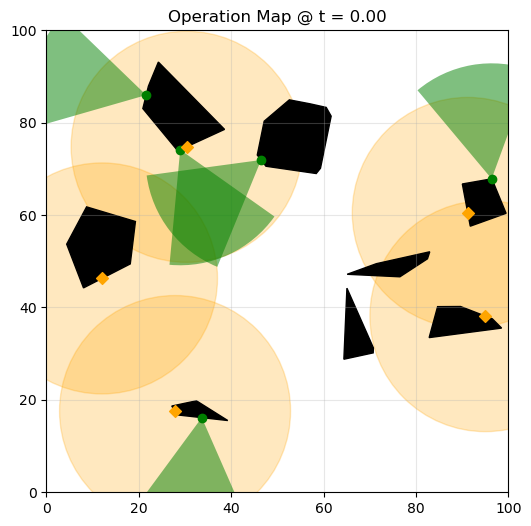

In [4]:
# Generate map
map_in, cam_dict = generate_map(
    map_size= map_size,
    num_buildings= num_buildings,
    num_directional_sensors= num_direc_sensor,
    num_omni_sensors= num_omni_sensor,
    fov_half_rad= fov_half_rad,
    max_range= max_range,
    fov_half_rad_omni= fov_half_rad,
    max_range_omni= max_range/2,
    panspeed_range= panspeed_range,
    cam_period= cam_period,
    cam_increment= cam_increment,
    rng_seed= rng_seed,
    balanced_sensors= False,
    param_lambda= [0.5, 0.5],
    param_beta= [0.4, 0.25]
)

# Parse map_in dictionarymap_size_val*0.1
map_size = map_in['st']['size']

visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5)

In [5]:
# Setup for Attacker Strategy: STP-RRT*
x0 = [0, 0, 0]
xf = [100, 100, 360]
vmax = 10

stp_rrt_setup = {}
stp_rrt_setup['x0'] = x0
stp_rrt_setup['xf'] = xf
stp_rrt_setup['vmax'] = vmax

# Output into JSON file
# Full path to the file
file_path1 = os.path.join("json/zero_sum_game", "operation_map.json")
file_path2 = os.path.join("json/zero_sum_game", "defender_info.json")
file_path3 = os.path.join("json/zero_sum_game", "stp_rrt_setup.json")

# Write JSON file into that folder
with open(file_path1, "w") as f:
    json.dump(make_json_serializable(map_in), f, indent=4)

with open(file_path2, "w") as f:
    json.dump(make_json_serializable(cam_dict), f, indent=4)

with open(file_path3, "w") as f:
    json.dump(stp_rrt_setup, f, indent=4)

In [6]:
# Generate Dynamic Map
dmap = DynamicMap(map_in, cam_dict)
map_in['dy'] = dmap

# Vehicle Spec
vehicle = {}
vehicle['v'] = vmax
vehicle['radius'] = 1

Initial Attacker Path generation with STP-RRT*
- if run_rrt = True: Run a new attacker path
- if run_rrt = False: load old attacker path

STP-RRT* initialized
Total Cost: 0.0


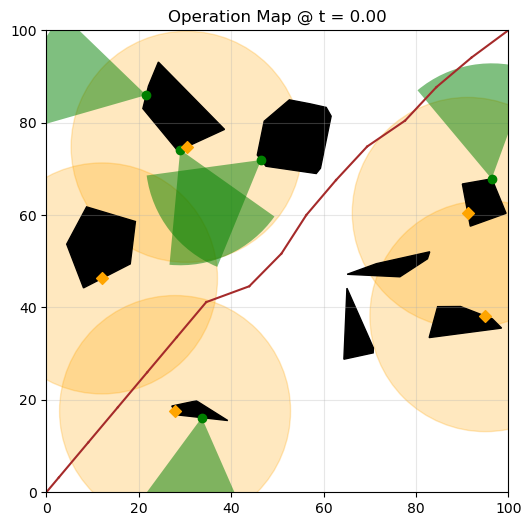

In [7]:
run_rrt = False
debug = True

# Initialize STP-RRT* Notebook
rrt_alg = rrt(vmax=vmax, xf=xf, map_size=map_size, vehicle=vehicle, cam_dict=cam_dict, dmap=dmap, max_time=1, map_in=map_in)

if run_rrt:
    
    # Run STP-RRT*
    # STP-RRT* Execution parameters
    x0 = x0          # start point
    nPartition = 5          # number of trees from the end point
    compTimeLimit = 300     # computation time limit

    min_dist = np.sqrt((x0[0]-xf[0])**2 + (x0[1]-xf[1])**2)
    min_time = min_dist/vmax

    tf0 = min_time                 # lower bound on end time randomization
    tfn = 25                # upper bound on end time randomization

    success_bool, comp_time, total_path_distance, total_path_time, success, path, V_start, V_goal, E_start, E_goal = rrt_alg.standard_Parallel_RRT(x0, nPartition, compTimeLimit, tf0, tfn, debug=debug)

    # Save Initial RRT result to a JSON File
    rrt_parameters={
        'success_bool': success_bool,
        'computation_time': comp_time,
        'path_distance': total_path_distance,
        'path_time': total_path_time,
        'path': path,
        'Vstart': V_start,
        'Vgoal': V_goal,
        'Estart': E_start,
        'Egoal': E_goal,
    }

    with open("json/zero_sum_game/rrt_parameters.json", "w") as f:
        json.dump(rrt_parameters, f, indent=4)
    print("STP-RRT* Results saved to rrt_parameters.json")
else:
    with open("json/zero_sum_game/rrt_parameters.json", 'r') as f:
    # with open("json/zero_sum_game/rrt_parameters_oscilation.json", 'r') as f:
        rrt_parameters = json.load(f)
        
    success_bool = rrt_parameters['success_bool']
    computation_time = rrt_parameters["computation_time"]
    total_path_distance = rrt_parameters["path_distance"]
    total_path_time = rrt_parameters["path_time"]
    path = rrt_parameters["path"]
    V_start = rrt_parameters["Vstart"]
    V_goal = rrt_parameters["Vgoal"]
    E_start = rrt_parameters["Estart"]
    E_goal = rrt_parameters["Egoal"]

# Visualize RRT result
visualize_map_at_time(map_in, cam_dict, t=0, sensor_alpha=0.5, algorithm_result=rrt_parameters)
print('Total Cost: '+str(rrt_alg.detection_cost_for_path(path)))

In [8]:
# Checking that the path obeys the maximum speed constraint
# Original Code written from Joseph
def verify_path_speed(path, vmax):
    """
    Verifies if any segment of the path exceeds vmax.
    Args:
        path: List of [x, y, t] points.
        vmax: Maximum allowed velocity.
    """
    # Convert to numpy array for easier calculation
    path_arr = np.array(path)
    
    # Calculate differences between consecutive points (dx, dy, dt)
    diffs = np.diff(path_arr, axis=0)
    dx = diffs[:, 0]
    dy = diffs[:, 1]
    dt = diffs[:, 2]

    # Calculate Euclidean distances
    distances = np.sqrt(dx**2 + dy**2)
    
    # Avoid division by zero issues
    # (If dt is 0, the speed is effectively infinite if dist > 0)
    dt_safe = np.maximum(dt, 1e-8) 
    
    # Calculate speeds: v = d / t
    speeds = distances / dt_safe

    # Identify violations
    # Using a small tolerance (1e-5) for floating point comparisons
    violation_indices = np.where(speeds > vmax + 1e-5)[0] 
    
    if len(violation_indices) > 0:
        print(f"⚠️ Speed Violation Detected: {len(violation_indices)} segments exceed vmax ({vmax})")
        print(f"   Maximum Speed Found: {np.max(speeds):.4f}")
        
        # Print the first few violations
        print("   First 3 violations:")
        for i in violation_indices[:3]:
            print(f"     Seg {i}->{i+1}: Speed={speeds[i]:.2f}, Dist={distances[i]:.2f}, Time={dt[i]:.4f}")
    else:
        print(f"✅ Path is valid. Max speed found: {np.max(speeds):.4f} (Limit: {vmax})")

# Run the check on your variables
verify_path_speed(path, vehicle['v'])

✅ Path is valid. Max speed found: 8.8511 (Limit: 10)


In [9]:
# Helper function to compute Half-Space parameters for a convex polygon
# Original code written by Joseph
def get_polygon_half_space_constraints(poly_vertices: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Computes A and b matrices for Ax <= b representation of a convex polygon.
    The constraint for avoidance will be A*p >= b + margin, or b - A*p <= -margin
    where p is the agent position.
    
    This function computes the *inward* pointing normal a_i and the offset b_i
    such that a_i^T * p <= b_i defines the INSIDE of the polygon.
    """
    
    A_list, b_list = [], []
    N_verts = len(poly_vertices)
    
    # Calculate centroid for inward/outward check
    # Note: polygon_centroid from convex_map uses NumPy but poly_vertices is a list of tuples initially
    # Ensure consistency; if poly_vertices is a NumPy array of (N, 2), this is fine.
    # We will use the centroid function from the imported convex_map
    centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])


        # CORRECTED CODE: Ensure poly_vertices is a list of tuples before passing to polygon_centroid
    # The map_in entry is a numpy array of arrays/lists (e.g., [[x1, y1], [x2, y2], ...])
    # We convert it back to the expected List[Tuple[float, float]] format for the utility function.
    # Let's ensure the inner elements are float/int pairs:
    if poly_vertices.ndim == 2:
        # This is a (N_verts, 2) array. Convert to a list of tuples.
        centroid = convex_map.polygon_centroid([tuple(v) for v in poly_vertices])
    else:
        # This must be the old [x, y, r] circular obstacle format that was accidentally left
        raise ValueError("Obstacle data is not a polygon vertex array. Check Cell 3 map setup.")
    
    for i in range(N_verts):
        v1 = poly_vertices[i]
        v2 = poly_vertices[(i + 1) % N_verts]
        
        # Edge vector (v2 - v1)
        ex, ey = v2[0] - v1[0], v2[1] - v1[1]
        
        # Candidate normal vector 1: n1 = (-ey, ex)
        # This is a counter-clockwise rotation from the edge vector (pointing left relative to edge direction v1->v2)
        n1 = np.array([-ey, ex])
        
        # Normalizing n1
        norm_n1 = np.linalg.norm(n1)
        if norm_n1 > 1e-6: # Avoid division by zero
            n1 = n1 / norm_n1

        # Check which normal points *inward* (toward the centroid)
        mid_point = (v1 + v2) / 2.0
        vec_to_centroid = np.array(centroid) - mid_point
        
        if np.dot(n1, vec_to_centroid) < 0:
            # n1 points OUT (Good!)
            a_i = n1
        else:
            # n1 points IN (Bad, flip it)
            a_i = -n1


            
        # Calculate the offset b_i using a point on the boundary (v1)
        b_i = np.dot(a_i, v1)
        
        A_list.append(a_i)
        b_list.append(b_i)

    # Return as NumPy arrays for CasADi/NumPy operations
    return np.array(A_list), np.array(b_list)

# Pre-calculate A and b for all buildings
obstacle_constraints = []
for i in range(map_in['st']['n']):
    # map_in['st'][str(i)] is an (N_verts, 2) numpy array of vertices
    poly_vertices = map_in['st'][str(i)]
    A, b = get_polygon_half_space_constraints(poly_vertices)
    obstacle_constraints.append({'A': A, 'b': b})

print(f"Pre-processed {len(obstacle_constraints)} convex polygon obstacles.")

Pre-processed 8 convex polygon obstacles.


CasADi Optimization
- Setup for optimization process using CasADi 


In [10]:
# Optimize defender with given attacker:
# For now, we only move camera positoin 
# Constraints: camera position only move along building edge

# Camera position parameterization
# Position of camera:
cam_x_direc = cam_dict['directional']['x']
cam_y_direc = cam_dict['directional']['y']
cam_x_omni = cam_dict['omnidirectional']['x']
cam_y_omni = cam_dict['omnidirectional']['y']

# Building param:
alpha_vec = []
building_edge_vec = []      # p0,j, start of building edge
building_vector_vec = []    # ve,j, direction of building edge

# Find edge of convex polygon with camera:
def closest_edge(building, cam_xy, tol=None):
    P = np.asarray(building, dtype=float)
    x = np.asarray(cam_xy, dtype=float)
    M = P.shape[0]
    assert M >= 3

    Pn = np.vstack([P, P[0]])
    Ls = np.linalg.norm(Pn[1:] - Pn[:-1], axis=1)
    Lmean = float(np.mean(Ls))
    if tol is None:
        tol = 1e-3 * Lmean if Lmean > 0 else 1e-6

    best = None
    for i in range(M):
        p0_i, p1_i = Pn[i], Pn[i+1]
        v_i = p1_i - p0_i
        L2 = float(v_i @ v_i)
        if L2 < 1e-16:
            continue
        t_raw = float((x - p0_i) @ v_i / L2)
        t_clamped = min(1.0, max(0.0, t_raw))
        proj_i = p0_i + t_clamped * v_i
        d2_i = float(np.sum((x - proj_i)**2))
        if (best is None) or (d2_i < best["d2"]):
            L = np.sqrt(L2)
            t_hat = v_i / L
            n_hat = np.array([-t_hat[1], t_hat[0]])
            best = dict(
                edge_idx=i, alpha=t_clamped, proj=proj_i, d2=d2_i,
                tangent=t_hat, normal=n_hat, p0=p0_i, p1=p1_i
            )

    dist = float(np.sqrt(best["d2"])) if best is not None else np.inf
    is_on = bool(dist <= tol)

    vertex_hit = None
    vdist = np.linalg.norm(P - x, axis=1)
    v_idx = int(np.argmin(vdist))
    if float(vdist[v_idx]) <= tol:
        vertex_hit = v_idx

    # *** CRITICAL: compute v_e from best['p1'] and best['p0'], not loop vars ***
    v_e = best["p1"] - best["p0"]

    best.update({
        "is_on_building": is_on,
        "distance": dist,
        "vertex_hit": vertex_hit,
        "tol_used": float(tol),
        "v_e": v_e
    })
    return best

# Directional Sensor
for n_building in range(map_in['st']['n']):
    for n_sensor in range(cam_dict['n_direc']):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_direc[n_sensor],cam_y_direc[n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])

# Omnidirectional Sensor            
for n_building in range(map_in['st']['n']):
    for n_sensor in range(cam_dict['n_omni']):
        pos_sensor_j = closest_edge(map_in['st'][str(n_building)], [cam_x_omni[n_sensor], cam_y_omni[n_sensor]])
        
        if pos_sensor_j['is_on_building']:
            alpha_vec.append(pos_sensor_j['alpha'])
            building_edge_vec.append(pos_sensor_j['p0'])
            building_vector_vec.append(pos_sensor_j['v_e'])
            
# print('alpha_j:'+str(alpha_vec))
# print('building_vec: '+str(building_vector_vec))
# print('building_edge: '+str(building_edge_vec))

In [11]:
# Cost function at given time ti
# Use Elfes's model
# Adopt method from Joseph's code:
# Distance decay variable
alpha_direc = 99/(cam_dict['directional']['spec']['fov'][1]**2)
alpha_omni = 99/(cam_dict['omnidirectional']['spec']['fov'][1]**2)

# Steepness of visibility
c_param = 10

def stage_detectability(x, y, t, S, camera_objects):
    """
    k(x, y, t; S) in [0, 1]
    x, y, t : casadi scalar of space-time vertex [x, y, t]
    """
    k_prod = 1.0
        
    for cam_i in range(cam_dict['n']):
        # Distances
        dx = x - S[0, cam_i]
        dy = y - S[1, cam_i]
        dist_sq = dx**2 + dy**2
        
        dist_min_sq = ca.fmax(dist_sq, 1e-4)
        dist_safe = ca.sqrt(dist_min_sq)
        
        # For directional sensors:
        if cam_i < cam_dict['n_direc']:
            cam = camera_objects[cam_i]
            phi = cam.get_ctr_theta_t(t)  # Use Camera.py method
            theta = cam.fov_ang
            cos_alpha = (dx*ca.cos(phi) + dy*ca.sin(phi))/dist_safe
            visibility = 1/(1+ca.exp(-c_param*(cos_alpha - ca.cos(theta/2))))
            observability = 1/(1+alpha_direc*dist_min_sq)
        else:
            visibility = 1
            observability = 1/(1+alpha_omni*dist_min_sq)
    
        k_j = visibility*observability
        k_prod *= (1 - k_j)
    
    # Probabilistic over sensors
    k_total = 1 - k_prod
    return k_total

# --- Generate Camera Objects ---
camera_objects = []
for i in range(cam_dict['n_direc']):
    cam_obj = Camera(i, cam_dict, cam_dict['directional']['x'][i], cam_dict['directional']['y'][i])
    camera_objects.append(cam_obj)

# Trajectory cost C(A, S)
M = cam_dict['n']
n_d = cam_dict['n_direc']

dt1_vec  = []
dt2_vec  = []
lam_vec  = []
beta_vec = []

for j in range(M):
    sensor_type = 'directional' if j < n_d else 'omnidirectional'

    dt1_vec.append(cam_dict[sensor_type]['spec']['fov'][1] / 100.0)
    dt2_vec.append(cam_dict[sensor_type]['spec']['fov'][1])
    lam_vec.append(cam_dict['detection'][sensor_type]['param_lambda'])
    beta_vec.append(cam_dict['detection'][sensor_type]['param_beta'])

dt1_vec  = np.array(dt1_vec, dtype=float)
dt2_vec  = np.array(dt2_vec, dtype=float)
lam_vec  = np.array(lam_vec, dtype=float)
beta_vec = np.array(beta_vec, dtype=float)

# def C_AS(A, S, dt1_vec, dt2_vec, lam_vec, beta_vec, eps=1e-9):
def C_AS(A, S, eps=1e-9):
    N = A.shape[1]
    C = 0
    for i in range(N):
        x_i = A[0, i]
        y_i = A[1, i]
        t_i = A[2, i]  # kept for signature compatibility (not used in pure range model)

        k_i = stage_detectability(x_i, y_i, t_i, S, camera_objects)
        C += -ca.log(1.0 - k_i + eps)
    return C

def build_C_function(N, M):
    A = ca.MX.sym('A', 3, N) # Attacker Trajectory
    S = ca.MX.sym('S', 2, M) # Defender Configuration
    C = C_AS(A, S)
    
    return ca.Function('DetectionCost', [A, S], [C], ['A', 'S'], ['cost'])

In [12]:
def optimize_defender(A_fixed, rho=0.0):
    opti_d = ca.Opti()

    # Defender Param
    total_number_of_sensors = cam_dict['n']
    total_directional_sensors = cam_dict['n_direc']
    total_omnidirectional_sensors = cam_dict['n_omni']

    alpha_j = opti_d.variable(total_number_of_sensors)

    # Add constraint for alpha_j
    opti_d.subject_to(alpha_j >= 0)
    opti_d.subject_to(alpha_j <= 1)

    # Setup sensor position S
    Sx = []
    Sy = []
    for j in range(total_number_of_sensors):
        p1 = building_edge_vec[j]
        s = p1 + alpha_j[j]*building_vector_vec[j]
        Sx.append(s[0])
        Sy.append(s[1])
        
    S = ca.vertcat(ca.hcat(Sx), ca.hcat(Sy)) #Shape 2, M

    # Attacker Param
    # path_arr = np.array(path)

    # rrt_x = path_arr[:, 0]
    # rrt_y = path_arr[:, 1]
    # rrt_t = path_arr[:, 2]

    # Number of evaluation points for defender cost
    # N_eval_defender = len(path_arr)
    N_eval_defender = A_fixed.shape[1]

    # Attacker trajectory parameter (fixed during defender solve)
    A_param = opti_d.parameter(3, N_eval_defender)
    # A_fixed = np.vstack([rrt_x, rrt_y, rrt_t]) # shape (3, N_eval_defender)
    opti_d.set_value(A_param, A_fixed)

    # Build Defender Objective
    # C = C_AS(A_param, S, dt1_vec, dt2_vec, lam_vec, beta_vec, eps=1e-9)
    C = C_AS(A_param, S)

    # Defender maximizes detection -> minimize -C (This is for single-iter)
    opti_d.minimize(-C)
    opti_d.set_initial(alpha_j, 0.5*np.ones(total_number_of_sensors))

    # Solver options
    p_opts = {
        "expand": False,
        "verbose": False,           # Ensures no extra CasADi debug info
        "print_time": False,
    }
    s_opts = {
        'max_iter': 3000,
        'tol': 1e-6,
        'acceptable_tol': 1e-4,
        'print_level': 0,
        "sb": "yes",                # Silences the Ipopt banner (the version info)
        "print_timing_statistics": "no", # Silences the final time summary
    }


    # Choose solver
    opti_d.solver('ipopt', p_opts, s_opts)


    # Solve
    try:
        sol_d = opti_d.solve()
        alpha_star = sol_d.value(alpha_j)
        S_star = sol_d.value(S)
        # S_star = np.column_stack([
        #     building_edge_vec[j] + alpha_star[j]*building_vector_vec[j] for j in range(M)
        # ])
        C_star = sol_d.value(C)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        alpha_star = opti_d.debug.value(alpha_j)
        S_star = opti_d.debug.value(S)
        C_star = opti_d.debug.value(C)
    return alpha_star, S_star, C_star, sol_d

In [13]:
def interpolate_rrt_path_preserve_speed(rrt_path, num_points):
        """
        Interpolates the original STP-RRT path using time-based interpolation,
        preserving the original speed profile.

        Parameters:
        - rrt_path: list of [x, y, t] points from STP-RRT
        - num_points: number of interpolated points to generate

        Returns:
        - x_interp: list of interpolated x positions
        - y_interp: list of interpolated y positions
        - t_interp: list of interpolated time values
        """
        rrt_array = np.array(rrt_path)
        x = rrt_array[:, 0]
        y = rrt_array[:, 1]
        t = rrt_array[:, 2]

        # Create interpolation functions for x(t) and y(t)
        fx = interp1d(t, x, kind='linear')
        fy = interp1d(t, y, kind='linear')

        # Generate evenly spaced time values
        t_interp = np.linspace(t[0], t[-1], num_points)

        # Interpolate positions
        x_interp = fx(t_interp)
        y_interp = fy(t_interp)

        return x_interp.tolist(), y_interp.tolist(), t_interp.tolist()

def optimize_attacker(S_fixed, S_star, N=1000):
    start_time = path[0][2]
    end_time = path[-1][2]

    opti_a = ca.Opti()

    # Set timestamps
    # N = 1000

    # Total travel time T as decision variable
    T = opti_a.variable()

    # Derived: per-step time
    dt = T/N

    opti_a.subject_to(T >= 1e-3)
    opti_a.subject_to(T <= end_time*1.5)

    # Decision_variables
    x_a = opti_a.variable(N+1)  # UAV x coords
    y_a = opti_a.variable(N+1)  # UAV y coords

    # Initial position constraints
    opti_a.subject_to(x_a[0] == x0[0])
    opti_a.subject_to(y_a[0] == x0[1])
    # Final position constraints
    opti_a.subject_to(x_a[-1] == xf[0])
    opti_a.subject_to(y_a[-1] == xf[1])
    # Map bounds
    opti_a.subject_to(opti_a.bounded(map_size[0], x_a, map_size[1]))
    opti_a.subject_to(opti_a.bounded(map_size[2], y_a, map_size[3]))

    # Max speed constraint
    for Ni in range(N):
        dx = x_a[Ni+1] - x_a[Ni]
        dy = y_a[Ni+1] - y_a[Ni]
        opti_a.subject_to(dx**2 + dy**2 <= (vmax*dt)**2)
    # dx = x_a[1:] - x_a[:-1]
    # dy = y_a[1:] - y_a[:-1]
    # opti_a.subject_to(dx**2 + dy**2 <= (vmax*dt)**2)
        
    # Anchor S_star in opti_a
    S_param = opti_a.parameter(2, cam_dict['n'])
    opti_a.set_value(S_param, S_star)

    # if we want for initial setup
    S_fixed = opti_a.parameter(2, cam_dict['n'])
    cam_direc_x = cam_dict['directional']['x']
    cam_direc_y = cam_dict['directional']['y']
    cam_omni_x = cam_dict['omnidirectional']['x']
    cam_omni_y = cam_dict['omnidirectional']['y']
    cam_x = np.hstack((cam_direc_x, cam_omni_x))
    cam_y = np.hstack((cam_direc_y, cam_omni_y))
    opti_a.set_value(S_fixed, np.vstack((cam_x, cam_y)))
        
    # Cost
    camera_objects = []
    for i in range(cam_dict['n_direc']):
        # Use S_star[0, i] and S_star[1, i] (the numeric results)
        cam_obj = Camera(i, cam_dict, float(S_star[0, i]), float(S_star[1, i]))
        camera_objects.append(cam_obj)

    log_sum = 0
    gamma = 500
    vehicle_radius = 1
    buffer_dist = 1
    safety_margin = vehicle_radius + buffer_dist
    for Ni in range(N):
        p_k = ca.vertcat(x_a[Ni], y_a[Ni])
        t_i = start_time + Ni*dt
        k_Ni = stage_detectability(x_a[Ni], y_a[Ni], t_i, S_param, camera_objects)
        current_log_term = ca.log(1 - k_Ni + 1e-9)
        log_sum += current_log_term
        
        # Static Obstacles
        for obs_data in obstacle_constraints:
            A_obs = obs_data['A']
            b_obs = obs_data['b']
            h_i_vector = ca.mtimes(A_obs, p_k) - b_obs
            
            # Number of edges in this polygon
            num_edges = A_obs.shape[0]
            
            # Log_sum-EXP constraint for obstacle avoidance
            max_h = h_i_vector[0]
            for idx in range(1, num_edges):
                max_h = ca.fmax(max_h, h_i_vector[idx])
            lse_term = max_h + (1.0/gamma) * ca.log(ca.sum(ca.exp(gamma * (h_i_vector - max_h))))
            lse_debiased = lse_term - (ca.log(num_edges) / gamma)
            
            opti_a.subject_to(lse_debiased >= safety_margin)
        
    # Time penalty to encourage shorter travel time
    time_penalty = 0.02*T

    # Total cost
    J_total_cost = log_sum - time_penalty

    opti_a.minimize(-J_total_cost)

    # Interpolating RRT initial guess
    x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N+1)

    # Use time-interpolated RRT as the initial guess
    opti_a.set_initial(x_a, x_interp)
    opti_a.set_initial(y_a, y_interp)
    T_init = float(path[-1][2]-path[0][2])
    opti_a.set_initial(T, T_init)

    # Obtain full symbolic decision variable vector
    w_sym = ca.vertcat(x_a, y_a, T)

    # Calculate log_sum for a particular path
    log_sum_evaluator = ca.Function('physical_cost_evaluator', [w_sym, S_param], [log_sum])
    # Calculate time penalty for a particular path
    penalty_cost_evaluator = ca.Function('penalty_cost_evaluator', [w_sym, S_param], [time_penalty])

    # Calculate PoD for initial path
    w0 = ca.vertcat(x_interp, y_interp, T_init)

    # Evaluate the log_sum for the initial path
    initial_log_sum_dm = log_sum_evaluator(w0, S_star)
    initial_log_sum_value = initial_log_sum_dm.full().item()
    # Evaluate the penalty cost for the initial path
    initial_penalty_cost_dm = penalty_cost_evaluator(w0, S_star)
    initial_penalty_cost_value = initial_penalty_cost_dm.full().item()

    # Calculate initial PoD of path
    initial_P_non_detection = np.exp(initial_log_sum_value)
    initial_P_detection = 1-initial_P_non_detection
    initial_total_cost = initial_log_sum_value - initial_penalty_cost_value

    # Solver options
    p_opts = {
        "expand": True,
        "verbose": False,           # Ensures no extra CasADi debug info
        "print_time": False,
    }
    s_opts = {
        'max_iter': 3000,
        'tol': 1e-6,
        'acceptable_tol': 1e-4,
        'print_level': 0,
        "sb": "yes",                # Silences the Ipopt banner (the version info)
        "print_timing_statistics": "no", # Silences the final time summary
    }

    # Solver
    opti_a.solver('ipopt', p_opts, s_opts)

    # Solve
    try:
        sol_a = opti_a.solve()
        x_a_opt = sol_a.value(x_a)
        y_a_opt = sol_a.value(y_a)
        T_opt = float(sol_a.value(T))
        log_sum_opt = sol_a.value(log_sum)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        x_a_opt = opti_a.debug.value(x_a)
        y_a_opt = opti_a.debug.value(y_a)
        T_opt = opti_a.debug.value(T)
        log_sum_opt = opti_a.debug.value(log_sum)

    # Build a numeric time vector for export / animation
    t_opt_num = np.linspace(start_time, start_time + T_opt, N+1)
    A_star = np.vstack((x_a_opt.T, y_a_opt.T, t_opt_num.T))
    return A_star, sol_a


In [14]:
############################################
# --- Attacker-Defender Iteratoin Setup ---
############################################
# Setup for iteration
# Initial attacker strategy A0
path_arr = np.array(path)
A_initial = path_arr.T
A_prev = A_initial.copy()

# Param for cycling
cycle_window = 4          # small, 3–6 is typical
cycle_tol = 1e-3          # how close two strategies must be to count as a repeat
eta_min = 0.05
eta_decay = 0.5

# Initial defender strategy alpha0
M = cam_dict['n']
eta = 0.3 # Damping factor (0 < eta <= 1)
rho = 1.0
alpha_init_vec = 0.5*np.ones(M)
# Corresponding initial sensor positions
S_init = np.column_stack([
    building_edge_vec[j]+alpha_init_vec[j]*building_vector_vec[j] for j in range(M)
])

# Alternative loop parameter
max_iters = 50
tol_alpha = 1e-3
tol_A = 1e-3
tol_cost = 1e-4
N_attk = 250 # Number of timestamp

# Sanity check:
print("Initial A shape:", A_initial.shape)   # (3, K)
print("Initial alpha:", alpha_init_vec)
print("Initial S shape:", S_init.shape)    # (2, M)

Initial A shape: (3, 16)
Initial alpha: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Initial S shape: (2, 10)


In [15]:
# Create symbolic representatives for the strategies
A_sym = ca.MX.sym('A_sym', A_initial.shape[0], N_attk+1)
S_sym = ca.MX.sym('S_sym', S_init.shape[0], S_init.shape[1])

# Create the symbolic cost expression using your existing C_AS function
# Ensure C_AS can handle symbolic MX inputs
J_sym = C_AS(A_sym, S_sym)
# 1. Flatten the matrices into vectors
A_flat = ca.reshape(A_sym, -1, 1)
S_flat = ca.reshape(S_sym, -1, 1)
z = ca.vertcat(A_flat, S_flat) # The combined game state

# 2. Define the game vector field (The 'Force' field)
# Attacker maximizes J (minimizes -J), Defender minimizes J
v = ca.vertcat(ca.reshape(ca.gradient(-J_sym, A_sym), -1, 1),
               ca.reshape(ca.gradient(J_sym, S_sym), -1, 1))

# 3. Compute the Game Jacobian
# This is a matrix of size (N_vars x N_vars)
J_game_expr = ca.jacobian(v, z)

# 4. Create the Evaluator
get_game_jacobian = ca.Function('gj', [A_sym, S_sym], [J_game_expr])

In [16]:
# Debugging check
debug = True

# Storage history
defender_cost_history = []
attacker_cost_history = []
payoff_history = []
alpha_history = []
A_history = []
S_history = []
stopping_criteria_log = {}
stopping_criteria_log['sensor_shift'] = []
stopping_criteria_log['cost_shift'] = []
stopping_criteria_log['eig_val'] = {}
stopping_criteria_log['eig_val']['eig_A'] = []
stopping_criteria_log['eig_val']['eig_S'] = []

sol_a_init = None
sol_d_init = None

J_A_at_ABR_vs_D_Init = 0
J_D_at_ABR_vs_D_Init = 0
J_A_at_DBR_vs_A_Init = 0
J_D_at_ABR_vs_A_Init = 0

# Initialization
alpha_prev_vec = alpha_init_vec.copy()
A_prev = A_initial.copy()
S_prev = S_init.copy()

# Cost at start of the iteration
J_tot_init = C_AS(A_initial, S_init, eps=1e-9)
prev_total_cost = 0
payoff_history.append(J_tot_init)

# Iteration
for attacker_defender_iter in range(max_iters):
    if debug:
        print('######################################################################')
        print('Iteration: '+str(attacker_defender_iter))
    # Storing old data
    alpha_old = alpha_prev_vec.copy()
    A_old = A_prev.copy()
    
    ######################################################################
    # --- Optimize defender strategy given fixed attacker strategy ---
    ######################################################################
    try:
        alpha_star, S_star, C_defender, sol_d = optimize_defender(A_fixed=A_prev, rho=rho)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        continue
    
    # Defender cost
    # J_def_k = C_AS(A_prev, S_star)
    # log_sum_def = float(sol_d.value(J_def_k))
    # val_def = 1.0 - np.exp(-log_sum_def)
    # defender_cost_history.append(val_def)
    J_def_k = C_AS(A_prev, S_star)
    if sol_d is not None:
        log_sum_def = float(sol_d.value(J_def_k))
    else:
        log_sum_def = float(J_def_k)
    val_def = 1.0 - np.exp(-log_sum_def)
    defender_cost_history.append(val_def)

    #####################################################################
    # --- Optimize attacker strategy given fixed defender strategy ---
    #####################################################################
    try:
        A_star, sol_a = optimize_attacker(S_fixed=S_prev, S_star=S_star, N=N_attk)
        # A_star = optimize_attacker(S_fixed=S_prev, S_star=S_star, N=N_attk)
    except RuntimeError as e:
        print('Magos, this machine spirit is tainted:', e)
        continue
    
    #  Attacker cost
    # J_att_k = C_AS(A_star, S_prev, eps=1e-9)
    # log_sum_att = float(sol_a.value(J_att_k))
    # val_att = 1.0 - np.exp(-log_sum_att)
    # attacker_cost_history.append(val_att)

    J_att_k = C_AS(A_star, S_prev, eps=1e-9)
    if sol_a is not None:
        log_sum_att = float(sol_a.value(J_att_k))
    else:
        log_sum_att = float(J_att_k)
    val_att = 1.0 - np.exp(-log_sum_att)
    attacker_cost_history.append(val_att)
    
    alpha_history.append(alpha_star.copy())
    A_history.append(A_star.copy())
    S_history.append(S_star.copy())

    if attacker_defender_iter == 1:
        sol_a_init = sol_a
        sol_d_init = sol_d

    #####
    J_A_at_ABR_vs_D_Init = sol_a.value(C_AS(A_prev, S_init, eps=1e-9))
    J_D_at_ABR_vs_D_Init = sol_d.value(C_AS(A_prev, S_init, eps=1e-9))
    J_A_at_DBR_vs_A_Init = sol_a.value(C_AS(A_initial, S_prev, eps=1e-9))
    J_D_at_ABR_vs_A_Init = sol_d.value(C_AS(A_initial, S_prev, eps=1e-9))

    #####################################################################
    #                  --- Update for next iteration ---
    #####################################################################
    # Total cost at given end of iteration
    J_total_k = C_AS(A_star, S_star)
    log_sum_total = float(sol_d.value(J_total_k))
    val_total = 1.0 - np.exp(-log_sum_total)
    payoff_history.append(val_total)
    
    ######################################################################
    #                    --- Stopping criteria ---
    ######################################################################
    # Convergence diagnostics
    # 1. Cost comparison
    current_total_cost = val_total
    cost_diff = abs(current_total_cost - prev_total_cost)
    # 2. Stability of strategy (avoid shifting or cycling of position while maintaining cost)
    sensor_shift = np.linalg.norm(S_star - S_prev)
    # 3. Stationary / KKT Error
    # Evaluate the Jacobian at the solution
    numeric_J = get_game_jacobian(A_star, S_star)
    numeric_J = np.array(numeric_J) # Convert to numpy for analysis

    # Calculate Eigenvalues
    # 1. Is the Attacker at a local minimum?
    size_A = 3 * (N_attk + 1)
    eig_A = np.linalg.eigvals(numeric_J[:size_A, :size_A])
    # 2. Is the Defender at a local minimum?
    eig_S = np.linalg.eigvals(numeric_J[size_A:, size_A:])
    min_eig_A = np.min(np.real(eig_A))
    min_eig_S = np.min(np.real(eig_S))
    
    # Log terminal conditions
    stopping_criteria_log['sensor_shift'].append(sensor_shift)
    stopping_criteria_log['cost_shift'].append(cost_diff)
    stopping_criteria_log['eig_val']['eig_A'].append(min_eig_A)
    stopping_criteria_log['eig_val']['eig_S'].append(min_eig_S)
    
    # --- 1. CONVERGENCE CHECK (Movement) ---
    # If sensors and costs stop changing, the players have "settled"
    is_stable = (sensor_shift < 1e-5) and (cost_diff < 1e-5)
    
    if is_stable:
        if min_eig_A > 1e-5 and min_eig_S >-1e-5:
            # Best local optimum
            equilibrium_type = 'Uncontrained Local Nash'
            print('Praise the Omnissiah. Convergence has achieved!')
            break
        else:
            # Best local optimum within feasible set. Actual NE is unreachable as its outside of feasible set
            equilibrium_type = 'Constrained Local Nash'
            print('Praise the Omnissiah. Convergence has achieved!')
            break
    elif attacker_defender_iter >= 50:
        print('Magos, we have reached for maximum iteration.')
        break
    else:
        print('Magos, the machine spirit has failed')
        print('Sensor shift: '+str(sensor_shift))
        print('Cost difference: '+str(cost_diff))
        prev_total_cost = current_total_cost
        
    # if attacker_defender_iter < 13:
    #     print('Magos, the machine spirit has failed')
    #     print('Sensor shift: '+str(sensor_shift))
    #     print('Cost difference: '+str(cost_diff))
    #     prev_total_cost = current_total_cost
    # else:
    #     break
    
    # if sensor_shift <1e-3 and cost_diff < tol_cost and min_eig_A > -1e-5 and min_eig_S > -1e-5:
    #     print('Praise the Omnissiah. Convergence has achieved!')
    #     break
    # else:not
    #     print('Magos, the machine spirit has failed')
    #     print(f'Sensor shift: {sensor_shift: .7f}')
    #     print(f'Cost difference: {cost_diff: .7f}')
    #     print(f"Attacker Min Eigenvalue: {min_eig_A:.7e}")
    #     print(f"Defender Min Eigenvalue: {min_eig_S:.7e}")
    #     prev_total_cost = current_total_cost
    
    # Update A_prev, S_prev
    # A_prev = A_star.copy()
    # S_prev = S_star.copy()
    eta = 0.3
    if attacker_defender_iter == 0:
        x_interp, y_interp, t_interp = interpolate_rrt_path_preserve_speed(path, N_attk+1)
        A_prev = np.vstack((x_interp, y_interp, t_interp))
    A_prev = (1 - eta) * A_prev + eta * A_star
    S_prev = (1 - eta) * S_prev + eta * S_star
    
    # for debugging
    if debug:
        print(f'Defender Cost: {val_def: .4f}')
        print(f'Attacker Cost: {val_att: .4f}')
        print(f'Overall Cost: {val_total: .4f}')

######################################################################
Iteration: 0
Magos, the machine spirit has failed
Sensor shift: 13.402772118032278
Cost difference: 0.8018002483197166
Defender Cost:  0.1837
Attacker Cost:  0.7855
Overall Cost:  0.8018
######################################################################
Iteration: 1
Magos, the machine spirit has failed
Sensor shift: 10.033591818361021
Cost difference: 0.0016082777368023882
Defender Cost:  0.9361
Attacker Cost:  0.7902
Overall Cost:  0.8002
######################################################################
Iteration: 2
Magos, the machine spirit has failed
Sensor shift: 7.024794048177362
Cost difference: 4.1723152099937266e-07
Defender Cost:  0.8959
Attacker Cost:  0.7928
Overall Cost:  0.8002
######################################################################
Iteration: 3
Magos, the machine spirit has failed
Sensor shift: 5.069568101273029
Cost difference: 0.0027631331283793914
Defender Cost:  0.8657
Attac

In [17]:
# --- Reusable numeric cost evaluator ---
# eval_C_numeric(A: 3×N, S: 2×M) -> scalar float
def eval_C_numeric(A_np, S_np):
    """Evaluate detection cost numerically given numpy arrays."""
    N = A_np.shape[1]
    M = S_np.shape[1]
    A_sym_ = ca.MX.sym('A_', 3, N)
    S_sym_ = ca.MX.sym('S_', 2, M)
    C_expr = C_AS(A_sym_, S_sym_)
    C_fn   = ca.Function('C_fn', [A_sym_, S_sym_], [C_expr])
    return float(C_fn(A_np, S_np))

In [18]:
# Build defender boundary constraints separately from attacker obstacle constraints
# For defender: A_def * x = b_def defines the building EDGE (not interior)
# Uses outward-pointing normals so R(x_j) = 0 places sensor on boundary

defender_boundary = []
for b_idx in range(map_in['st']['n']):
    verts  = np.array(map_in['st'][str(b_idx)], dtype=float)
    N_v    = len(verts)
    A_list = []
    b_list = []
    centroid = np.mean(verts, axis=0)

    for i in range(N_v):
        v1 = verts[i]
        v2 = verts[(i+1) % N_v]
        ex, ey = v2[0]-v1[0], v2[1]-v1[1]
        # Outward normal: perpendicular to edge, pointing away from centroid
        n = np.array([-ey, ex])
        n = n / (np.linalg.norm(n) + 1e-12)
        mid = (v1 + v2) / 2.0
        # Ensure outward direction
        if np.dot(n, mid - centroid) < 0:
            n = -n
        b_i = np.dot(n, v1)
        A_list.append(n)
        b_list.append(b_i)

    defender_boundary.append({
        'A': np.array(A_list),   # outward normals: A*x >= b means outside
        'b': np.array(b_list)
    })

# Compute correct building assignment from actual sensor positions
# Using S_star as reference (ABR-converged positions)
def find_sensor_building(xy, defender_boundary):
    """Find which building a sensor position belongs to."""
    best_bldg = -1
    best_dist = np.inf
    for b_idx in range(len(defender_boundary)):
        A_d   = defender_boundary[b_idx]['A']
        b_d   = defender_boundary[b_idx]['b']
        max_v = np.max(A_d @ xy - b_d)
        if max_v < best_dist:
            best_dist = max_v
            best_bldg = b_idx
    return best_bldg

sensor_building_idx = []
for j in range(cam_dict['n']):
    b = find_sensor_building(S_star[:, j], defender_boundary)
    sensor_building_idx.append(b)

print("Corrected sensor -> building assignments:", sensor_building_idx)

b_idx = sensor_building_idx[0]
A_d = defender_boundary[b_idx]['A']
b_d = defender_boundary[b_idx]['b']
print("Sensor 0 boundary check (A*x - b, should have one ~0 value):")
print(A_d @ S_star[:,0] - b_d)

Corrected sensor -> building assignments: [2, 2, 4, 5, 7, 1, 2, 5, 6, 7]
Sensor 0 boundary check (A*x - b, should have one ~0 value):
[-1.07589989e+01  0.00000000e+00 -7.41750012e-04 -1.88017137e+01
 -1.82487633e+01]


=== ABR result (for reference) ===
  C(A_abr, S_abr) = 1.637592  |  P_D = 0.805552

Praise the Omnissiah. Engaging simultaneous KKT solve...
  Machine spirit faltered: Error in Opti::solve [OptiNode] at .../casadi/core/optistack.cpp:217:
.../casadi/core/optistack_internal.cpp:1338: Assertion "return_success(accept_limit)" failed:
Solver failed. You may use opti.debug.value to investigate the latest values of variables. return_status is 'Maximum_Iterations_Exceeded'
  Debug. Max defender stationarity residual: 6.6277e-03
  C(A_kkt, S_kkt) = 1.128937
  P_D at KKT      = 0.676623

=== Nash Equilibrium Verification ===
  C(A_abr, S_kkt) = 1.161984  <- attacker deviation
  C(A_kkt, S_kkt) = 1.128937  <- KKT payoff
  Attacker gain:    3.3046e-02  (>= 0: A_kkt better for attacker)
  C(A_kkt, S_abr) = 1.749751  <- defender deviation
  C(A_kkt, S_kkt) = 1.128937  <- KKT payoff
  Defender gain:    -6.2081e-01  (>= 0: S_kkt better for defender)

  ABR: C=1.637592  P_D=0.805552
  KKT: C=1.128937  

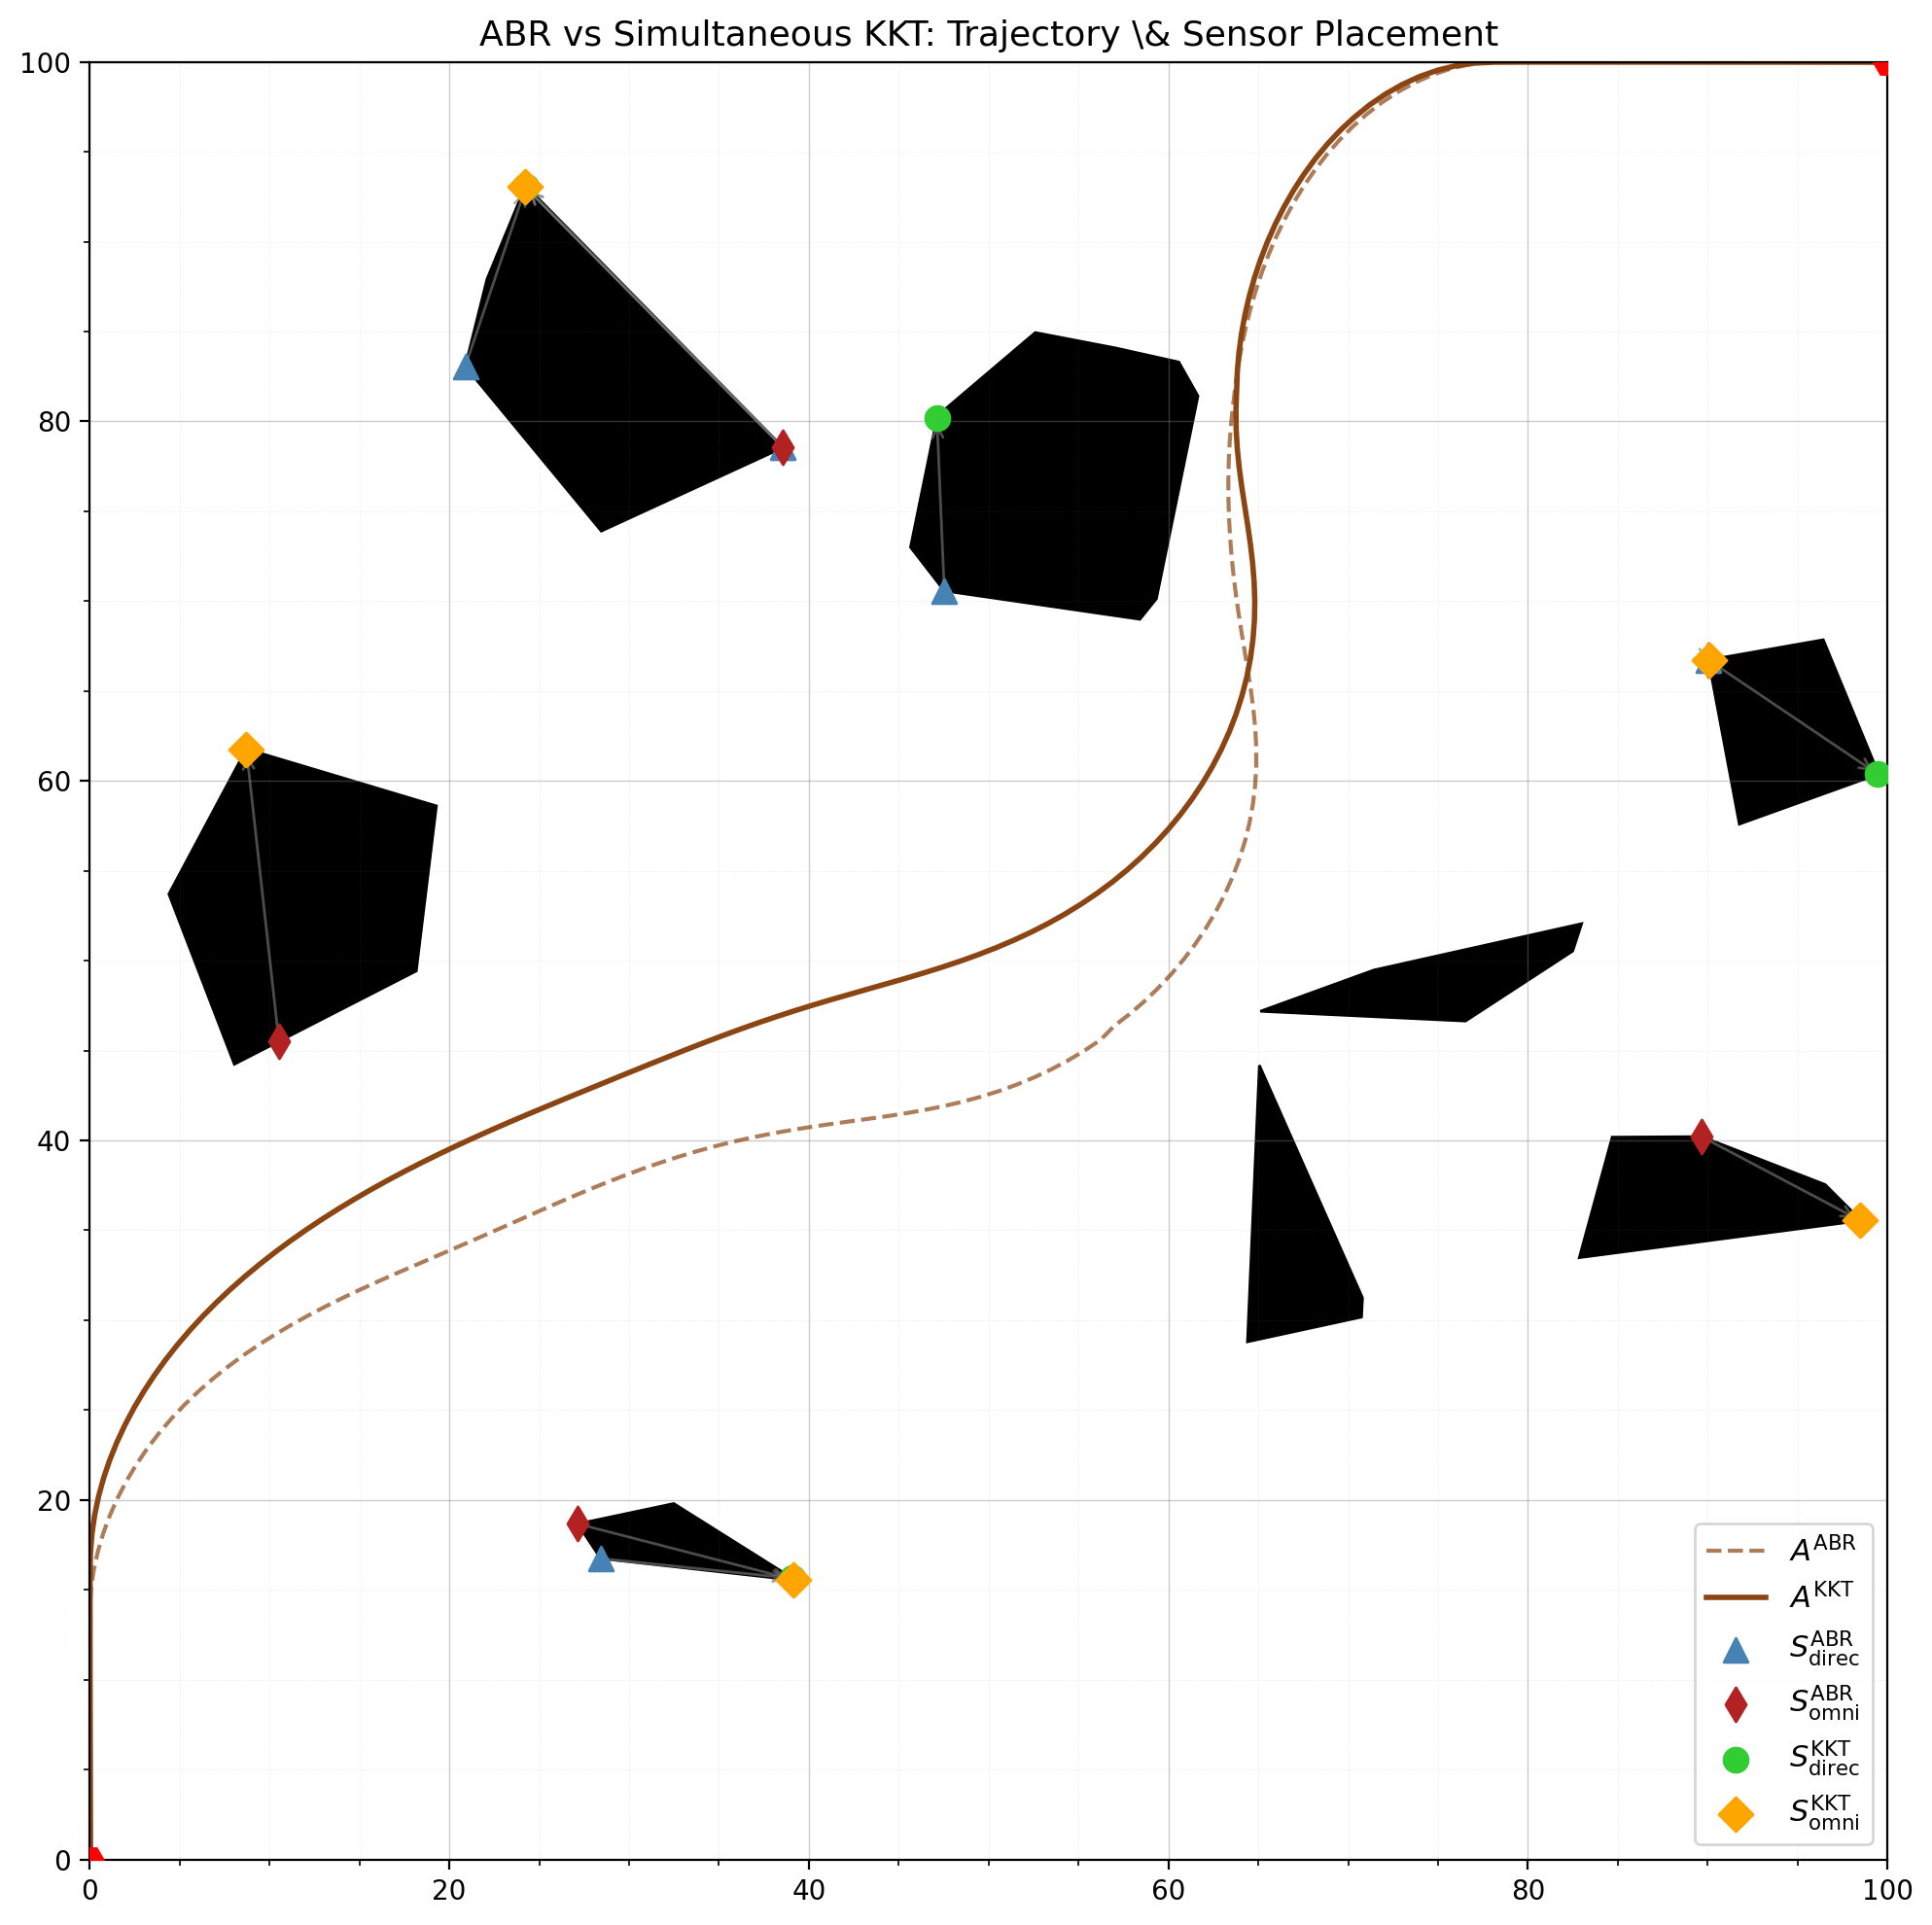

Simultaneous KKT solve complete.


In [19]:
##############################################################################
# --- Single IPOPT Simultaneous Optimization: KKT Reformulation ---
#
# Formulation (single-level NLP):
#
#   minimize_{A, Sx, Sy}   C(A, S)          <- attacker minimizes
#   subject to:
#     Attacker constraints:
#       - boundary: x[0]=x0, y[0]=y0, x[-1]=xf, y[-1]=yf
#       - speed:    ||p[k+1]-p[k]||^2 <= (vmax*dt)^2
#       - map bounds
#       - obstacle avoidance (log-sum-exp)
#     Defender stationarity (KKT of defender's maximization):
#       grad_{Sx_j} C(A,S) = 0,  j=1..M     <- 10 equations
#       grad_{Sy_j} C(A,S) = 0,  j=1..M     <- 10 equations
#     Defender boundary (IPOPT handles KKT multipliers):
#       R(x_j) = 0  for each sensor j        <- 10 equations
#
# Total variables: (2N+3) + 2M = 503 + 20 = 523
# Total equality constraints:
#   - attacker boundary: 4
#   - defender stationarity: 20
#   - defender boundary: 10
#   Total: 34  <<< NOT overconstrained
#
# Key insight: grad_S C = 0 is only 2M=20 equations (one per sensor coordinate)
# NOT 2N+3 equations. This is what was overconstrained before — we were
# enforcing grad_A = 0 (503 eqs) which conflicted with attacker boundary (4 eqs).
# Here we only enforce grad_S = 0 for the DEFENDER (20 eqs) and let IPOPT
# minimize C for the ATTACKER — this is the correct KKT reformulation.
##############################################################################

from scipy.interpolate import interp1d


cam_x_all = np.hstack([cam_dict['directional']['x'],
                        cam_dict['omnidirectional']['x']])
cam_y_all = np.hstack([cam_dict['directional']['y'],
                        cam_dict['omnidirectional']['y']])


def optimize_simultaneous_kkt(A_init_np, S_init_np, N=None):
    """
    Single IPOPT solve: attacker minimizes C, defender stationarity
    enforced as equality constraints (KKT reformulation).

    Variables: (x_a, y_a, T) for attacker + (Sx, Sy) for defender
    Objective: C(A, S)  — attacker minimizes detection
    Constraints:
      - Attacker: boundary, speed, map bounds, obstacle avoidance
      - Defender stationarity: grad_{Sx_j} C = 0, grad_{Sy_j} C = 0
      - Defender boundary: R(x_j) = 0 via log-sum-exp
    """
    if N is None:
        N = N_attk

    start_time  = path[0][2]
    end_time    = path[-1][2]
    M_sensors   = cam_dict['n']
    eps_lse     = 0.05   # log-sum-exp smoothing for boundary

    opti = ca.Opti()

    # ---------------------------------------------------------------- #
    #  Decision variables
    # ---------------------------------------------------------------- #
    x_a  = opti.variable(N + 1)     # attacker x
    y_a  = opti.variable(N + 1)     # attacker y
    T    = opti.variable()           # attacker total time
    Sx   = opti.variable(M_sensors)  # defender x positions
    Sy   = opti.variable(M_sensors)  # defender y positions

    dt = T / N

    # ---------------------------------------------------------------- #
    #  Sensor position matrix
    # ---------------------------------------------------------------- #
    S_mat = ca.vertcat(
        ca.reshape(Sx, 1, M_sensors),
        ca.reshape(Sy, 1, M_sensors)
    )  # (2, M)

    # ---------------------------------------------------------------- #
    #  Camera objects for pan angles
    # ---------------------------------------------------------------- #
    cam_objs = []
    for i in range(cam_dict['n_direc']):
        cam_objs.append(Camera(i, cam_dict,
                               float(cam_x_all[i]),
                               float(cam_y_all[i])))

    # ---------------------------------------------------------------- #
    #  Detection cost C(A, S)
    # ---------------------------------------------------------------- #
    t_nodes = [start_time + i * dt for i in range(N + 1)]
    log_sum = 0
    for i in range(N + 1):
        xi = x_a[i]; yi = y_a[i]; ti = t_nodes[i]
        k_prod = 1.0
        for cam_i in range(M_sensors):
            dx_i      = xi - S_mat[0, cam_i]
            dy_i      = yi - S_mat[1, cam_i]
            dist_sq   = dx_i**2 + dy_i**2
            dist_min  = ca.fmax(dist_sq, 1e-4)
            dist_safe = ca.sqrt(dist_min)
            if cam_i < cam_dict['n_direc']:
                cam_obj = cam_objs[cam_i]
                phi     = cam_obj.get_ctr_theta_t(ti)
                theta   = cam_obj.fov_ang
                cos_a   = (dx_i*ca.cos(phi) + dy_i*ca.sin(phi)) / dist_safe
                vis     = 1 / (1 + ca.exp(-c_param*(cos_a - ca.cos(theta/2))))
                obs_r   = 1 / (1 + alpha_direc*dist_min)
            else:
                vis   = 1.0
                obs_r = 1 / (1 + alpha_omni*dist_min)
            k_j     = vis * obs_r
            k_prod *= (1 - k_j)
        k_total  = 1 - k_prod
        log_sum += -ca.log(1.0 - k_total + 1e-9)

    time_penalty = 0.02 * T
    C_joint = log_sum - time_penalty

    # ---------------------------------------------------------------- #
    #  Objective: attacker minimizes C
    # ---------------------------------------------------------------- #
    opti.minimize(C_joint)

    # ---------------------------------------------------------------- #
    #  Attacker constraints
    # ---------------------------------------------------------------- #
    opti.subject_to(T >= 1e-3)
    opti.subject_to(T <= end_time * 1.5)
    opti.subject_to(x_a[0] == x0[0])
    opti.subject_to(y_a[0] == x0[1])
    opti.subject_to(x_a[-1] == xf[0])
    opti.subject_to(y_a[-1] == xf[1])
    opti.subject_to(opti.bounded(map_size[0], x_a, map_size[1]))
    opti.subject_to(opti.bounded(map_size[2], y_a, map_size[3]))

    for k in range(N):
        dx_s = x_a[k+1] - x_a[k]
        dy_s = y_a[k+1] - y_a[k]
        opti.subject_to(dx_s**2 + dy_s**2 <= (vmax * dt)**2)

    # Obstacle avoidance
    gamma_obs     = 500
    safety_margin = vehicle['radius'] + 1
    for k in range(N + 1):
        p_k = ca.vertcat(x_a[k], y_a[k])
        for obs_data in obstacle_constraints:
            A_obs   = obs_data['A']
            b_obs   = obs_data['b']
            h_vec   = ca.mtimes(A_obs, p_k) - b_obs
            n_edges = A_obs.shape[0]
            max_h   = h_vec[0]
            for idx in range(1, n_edges):
                max_h = ca.fmax(max_h, h_vec[idx])
            lse     = max_h + (1.0/gamma_obs)*ca.log(
                ca.sum(ca.exp(gamma_obs*(h_vec - max_h))))
            lse_deb = lse - (ca.log(n_edges)/gamma_obs)
            opti.subject_to(lse_deb >= safety_margin)

    # ---------------------------------------------------------------- #
    #  Defender stationarity: grad_{Sx_j} C = 0, grad_{Sy_j} C = 0
    #  This is the KKT condition for the defender's maximization.
    #  IPOPT handles the boundary KKT multipliers automatically via R(x_j)=0.
    # ---------------------------------------------------------------- #
    w_D    = ca.vertcat(Sx, Sy)          # (2M,) defender variables
    grad_D = ca.gradient(C_joint, w_D)   # (2M,) unconstrained gradient

    # for j in range(M_sensors):
    #     opti.subject_to(grad_D[j] == 0)            # grad wrt Sx_j = 0
    #     opti.subject_to(grad_D[M_sensors + j] == 0) # grad wrt Sy_j = 0
    
    # CORRECT: grad_D + mu_j * grad_R = 0  (includes boundary force)
    # Introduce KKT multipliers mu_j as additional variables
    mu = opti.variable(M_sensors)   # one multiplier per sensor

    for j in range(M_sensors):
        # grad_R at sensor j
        b_idx  = sensor_building_idx[j]
        A_obs  = obstacle_constraints[b_idx]['A']
        b_obs  = obstacle_constraints[b_idx]['b']
        Me     = A_obs.shape[0]

        logits = ca.MX.zeros(Me)
        for k in range(Me):
            logits[k] = (A_obs[k,0]*Sx[j] + A_obs[k,1]*Sy[j] - b_obs[k]) / eps_lse
            # logits[k] = -(A_obs[k,0]*Sx[j] + A_obs[k,1]*Sy[j] - b_obs[k]) / eps_lse
        logits_max = logits[0]
        for k in range(1, Me):
            logits_max = ca.fmax(logits_max, logits[k])
        w = ca.exp(logits - logits_max)
        w = w / ca.sum(w)
        # grad_R = -A^T w  (shape: 2,)
        grad_Rx = -ca.dot(A_obs[:,0], w)
        grad_Ry = -ca.dot(A_obs[:,1], w)

        # KKT: grad_{Sx_j} C + mu_j * grad_Rx = 0
        # KKT: grad_{Sy_j} C + mu_j * grad_Ry = 0
        # opti.subject_to(grad_D[j]            + mu[j] * grad_Rx == 0)
        # opti.subject_to(grad_D[M_sensors+j]  + mu[j] * grad_Ry == 0)
        stationarity_penalty = 0
        for j in range(M_sensors):
            # ... compute grad_Rx, grad_Ry as before ...
            stationarity_penalty += (grad_D[j] - mu[j] * grad_Rx)**2
            stationarity_penalty += (grad_D[M_sensors+j] - mu[j] * grad_Ry)**2

        lambda_kkt = 100
        opti.minimize(C_joint + lambda_kkt * stationarity_penalty)

    # ---------------------------------------------------------------- #
    #  Defender boundary: R(x_j) = 0 (log-sum-exp smooth boundary)
    #  IPOPT treats this as an equality constraint and computes KKT
    #  multipliers mu_j automatically — this is Eq. 21 from the paper
    # ---------------------------------------------------------------- #
    for j in range(M_sensors):
        b_idx = sensor_building_idx[j]
        A_obs = defender_boundary[b_idx]['A']
        b_obs = defender_boundary[b_idx]['b']
        Me    = A_obs.shape[0]

        x_j   = ca.vertcat(Sx[j], Sy[j])
        # R(x_j) = -eps * log(sum(exp((A^T x - b) / eps)))
        logits = ca.MX.zeros(Me)
        for k in range(Me):
            logits[k] = (A_obs[k, 0]*Sx[j] + A_obs[k, 1]*Sy[j] - b_obs[k]) / eps_lse
            # logits[k] = -(A_obs[k,0]*Sx[j] + A_obs[k,1]*Sy[j] - b_obs[k]) / eps_lse

        # log-sum-exp: R = -eps * log(sum(exp(logits)))
        # Stabilized: R = -eps * (max + log(sum(exp(logits - max))))
        logits_max = logits[0]
        for k in range(1, Me):
            logits_max = ca.fmax(logits_max, logits[k])
        R_j = -eps_lse * (logits_max +
                           ca.log(ca.sum(ca.exp(logits - logits_max))))
        opti.subject_to(R_j == 0)

        # Also enforce half-space: sensor inside/on building
        for k in range(Me):
            opti.subject_to(
                A_obs[k, 0]*Sx[j] + A_obs[k, 1]*Sy[j] <= b_obs[k]
            )

    # ---------------------------------------------------------------- #
    #  Warm start
    # ---------------------------------------------------------------- #
    # Interpolate attacker path
    x_interp, y_interp, t_interp = [], [], []
    path_arr = np.array(path)
    fx = interp1d(path_arr[:,2], path_arr[:,0], kind='linear')
    fy = interp1d(path_arr[:,2], path_arr[:,1], kind='linear')
    t_new = np.linspace(path_arr[0,2], path_arr[-1,2], N+1)
    x_interp = fx(t_new); y_interp = fy(t_new)

    opti.set_initial(x_a, A_init_np[0,:])
    opti.set_initial(y_a, A_init_np[1,:])
    opti.set_initial(T,   float(A_init_np[2,-1] - A_init_np[2,0]))
    opti.set_initial(Sx,  S_init_np[0,:])
    opti.set_initial(Sy,  S_init_np[1,:])

    # ---------------------------------------------------------------- #
    #  Solver options
    # ---------------------------------------------------------------- #
    p_opts = {"expand": True, "verbose": False, "print_time": False}
    s_opts = {
        'max_iter':                500,
        'tol':                     1e-5,
        'acceptable_tol':          1e-4,
        'print_level':             0,
        'sb':                      'yes',
        'print_timing_statistics': 'no',
    }
    opti.solver('ipopt', p_opts, s_opts)

    # ---------------------------------------------------------------- #
    #  Solve
    # ---------------------------------------------------------------- #
    print('Praise the Omnissiah. Engaging simultaneous KKT solve...')
    try:
        sol      = opti.solve()
        x_opt    = sol.value(x_a)
        y_opt    = sol.value(y_a)
        T_opt    = float(sol.value(T))
        Sx_opt   = sol.value(Sx)
        Sy_opt   = sol.value(Sy)
        gD_res   = np.array(sol.value(grad_D)).flatten()
        print(f'  Solved.')
        print(f'  Max defender stationarity residual: '
              f'{np.max(np.abs(gD_res)):.4e}  (should be ~0)')
    except RuntimeError as e:
        print(f'  Machine spirit faltered: {e}')
        x_opt  = opti.debug.value(x_a)
        y_opt  = opti.debug.value(y_a)
        T_opt  = float(opti.debug.value(T))
        Sx_opt = opti.debug.value(Sx)
        Sy_opt = opti.debug.value(Sy)
        gD_res = np.array(opti.debug.value(grad_D)).flatten()
        print(f'  Debug. Max defender stationarity residual: '
              f'{np.max(np.abs(gD_res)):.4e}')

    t_opt  = np.linspace(start_time, start_time + T_opt, N+1)
    A_kkt  = np.vstack((x_opt, y_opt, t_opt))
    S_kkt  = np.vstack((Sx_opt, Sy_opt))

    C_kkt = eval_C_numeric(A_kkt, S_kkt)
    print(f'  C(A_kkt, S_kkt) = {C_kkt:.6f}')
    print(f'  P_D at KKT      = {1 - np.exp(-C_kkt):.6f}')

    return A_kkt, S_kkt, C_kkt


##############################################################################
# --- Run simultaneous KKT solve ---
##############################################################################
print('=== ABR result (for reference) ===')
C_abr = eval_C_numeric(A_star, S_star)
print(f'  C(A_abr, S_abr) = {C_abr:.6f}  |  P_D = {1-np.exp(-C_abr):.6f}')
print()

A_kkt, S_kkt, C_kkt_val = optimize_simultaneous_kkt(
    A_init_np = A_star,
    S_init_np = S_star,
    N         = N_attk,
)

##############################################################################
# --- Nash Equilibrium Verification ---
##############################################################################
print()
print('=== Nash Equilibrium Verification ===')
C_abr_val  = eval_C_numeric(A_star, S_star)
C_kkt_val2 = eval_C_numeric(A_kkt,  S_kkt)

C_Aabr_Skkt = eval_C_numeric(A_star, S_kkt)
print(f'  C(A_abr, S_kkt) = {C_Aabr_Skkt:.6f}  <- attacker deviation')
print(f'  C(A_kkt, S_kkt) = {C_kkt_val2:.6f}  <- KKT payoff')
print(f'  Attacker gain:    {C_Aabr_Skkt - C_kkt_val2:.4e}'
      f'  (>= 0: A_kkt better for attacker)')

C_Akkt_Sabr = eval_C_numeric(A_kkt, S_star)
print(f'  C(A_kkt, S_abr) = {C_Akkt_Sabr:.6f}  <- defender deviation')
print(f'  C(A_kkt, S_kkt) = {C_kkt_val2:.6f}  <- KKT payoff')
print(f'  Defender gain:    {C_kkt_val2 - C_Akkt_Sabr:.4e}'
      f'  (>= 0: S_kkt better for defender)')

print()
print(f'  ABR: C={C_abr_val:.6f}  P_D={1-np.exp(-C_abr_val):.6f}')
print(f'  KKT: C={C_kkt_val2:.6f}  P_D={1-np.exp(-C_kkt_val2):.6f}')

##############################################################################
# --- Map plot ---
##############################################################################
fig_kkt, ax_kkt = plt.subplots(figsize=(10, 10), dpi=200)
st_  = map_in['st']
sz   = np.array(st_['size'], dtype=float)
xmn, xmx, ymn, ymx = sz

for i in range(st_['n']):
    ax_kkt.add_patch(PolyPatch(
        np.array(st_[str(i)], dtype=float),
        closed=True, facecolor='black', edgecolor='black'))

ax_kkt.plot(A_star[0,:], A_star[1,:], '--',
             color='saddlebrown', lw=1.5, alpha=0.7, label=r'$A^{\rm ABR}$')
ax_kkt.plot(A_kkt[0,:],  A_kkt[1,:],  '-',
             color='saddlebrown', lw=2.0, label=r'$A^{\rm KKT}$')
ax_kkt.scatter(S_star[0,:num_direc_sensor], S_star[1,:num_direc_sensor],
                s=80, marker='^', color='steelblue', zorder=5,
                label=r'$S^{\rm ABR}_{\rm direc}$')
ax_kkt.scatter(S_star[0,num_direc_sensor:], S_star[1,num_direc_sensor:],
                s=80, marker='d', color='firebrick', zorder=5,
                label=r'$S^{\rm ABR}_{\rm omni}$')
ax_kkt.scatter(S_kkt[0,:num_direc_sensor],  S_kkt[1,:num_direc_sensor],
                s=80, marker='o', color='limegreen', zorder=6,
                label=r'$S^{\rm KKT}_{\rm direc}$')
ax_kkt.scatter(S_kkt[0,num_direc_sensor:],  S_kkt[1,num_direc_sensor:],
                s=80, marker='D', color='orange', zorder=6,
                label=r'$S^{\rm KKT}_{\rm omni}$')

for j in range(cam_dict['n']):
    ax_kkt.annotate('',
        xy    =(S_kkt[0,j],  S_kkt[1,j]),
        xytext=(S_star[0,j], S_star[1,j]),
        arrowprops=dict(arrowstyle='->', color='gray', lw=1.0, alpha=0.6))

ax_kkt.plot(x0[0], x0[1], 'H', c='red', markersize=10, zorder=10)
ax_kkt.plot(xf[0], xf[1], 'H', c='red', markersize=10, zorder=10)
ax_kkt.set_xlim(xmn, xmx); ax_kkt.set_ylim(ymn, ymx)
ax_kkt.set_aspect('equal'); ax_kkt.minorticks_on()
ax_kkt.grid(which='major', linestyle='-',  lw=0.5, color='gray', alpha=0.4)
ax_kkt.grid(which='minor', linestyle=':',  lw=0.3, color='gray', alpha=0.2)
ax_kkt.legend(loc='lower right', fontsize=11)
ax_kkt.set_title(r'ABR vs Simultaneous KKT: Trajectory \& Sensor Placement',
                  fontsize=13)
plt.tight_layout()
plt.savefig('image/AD_Game/'+timestamp+'_KKT_map.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Simultaneous KKT solve complete.')


||grad_A|| at KKT = 2.1212e-02
||grad_D|| at KKT = 1.4713e-02
C at KKT:           0.595006
Evaluating C on 6x6 grid...
  Row 5/6 done
Grid complete.


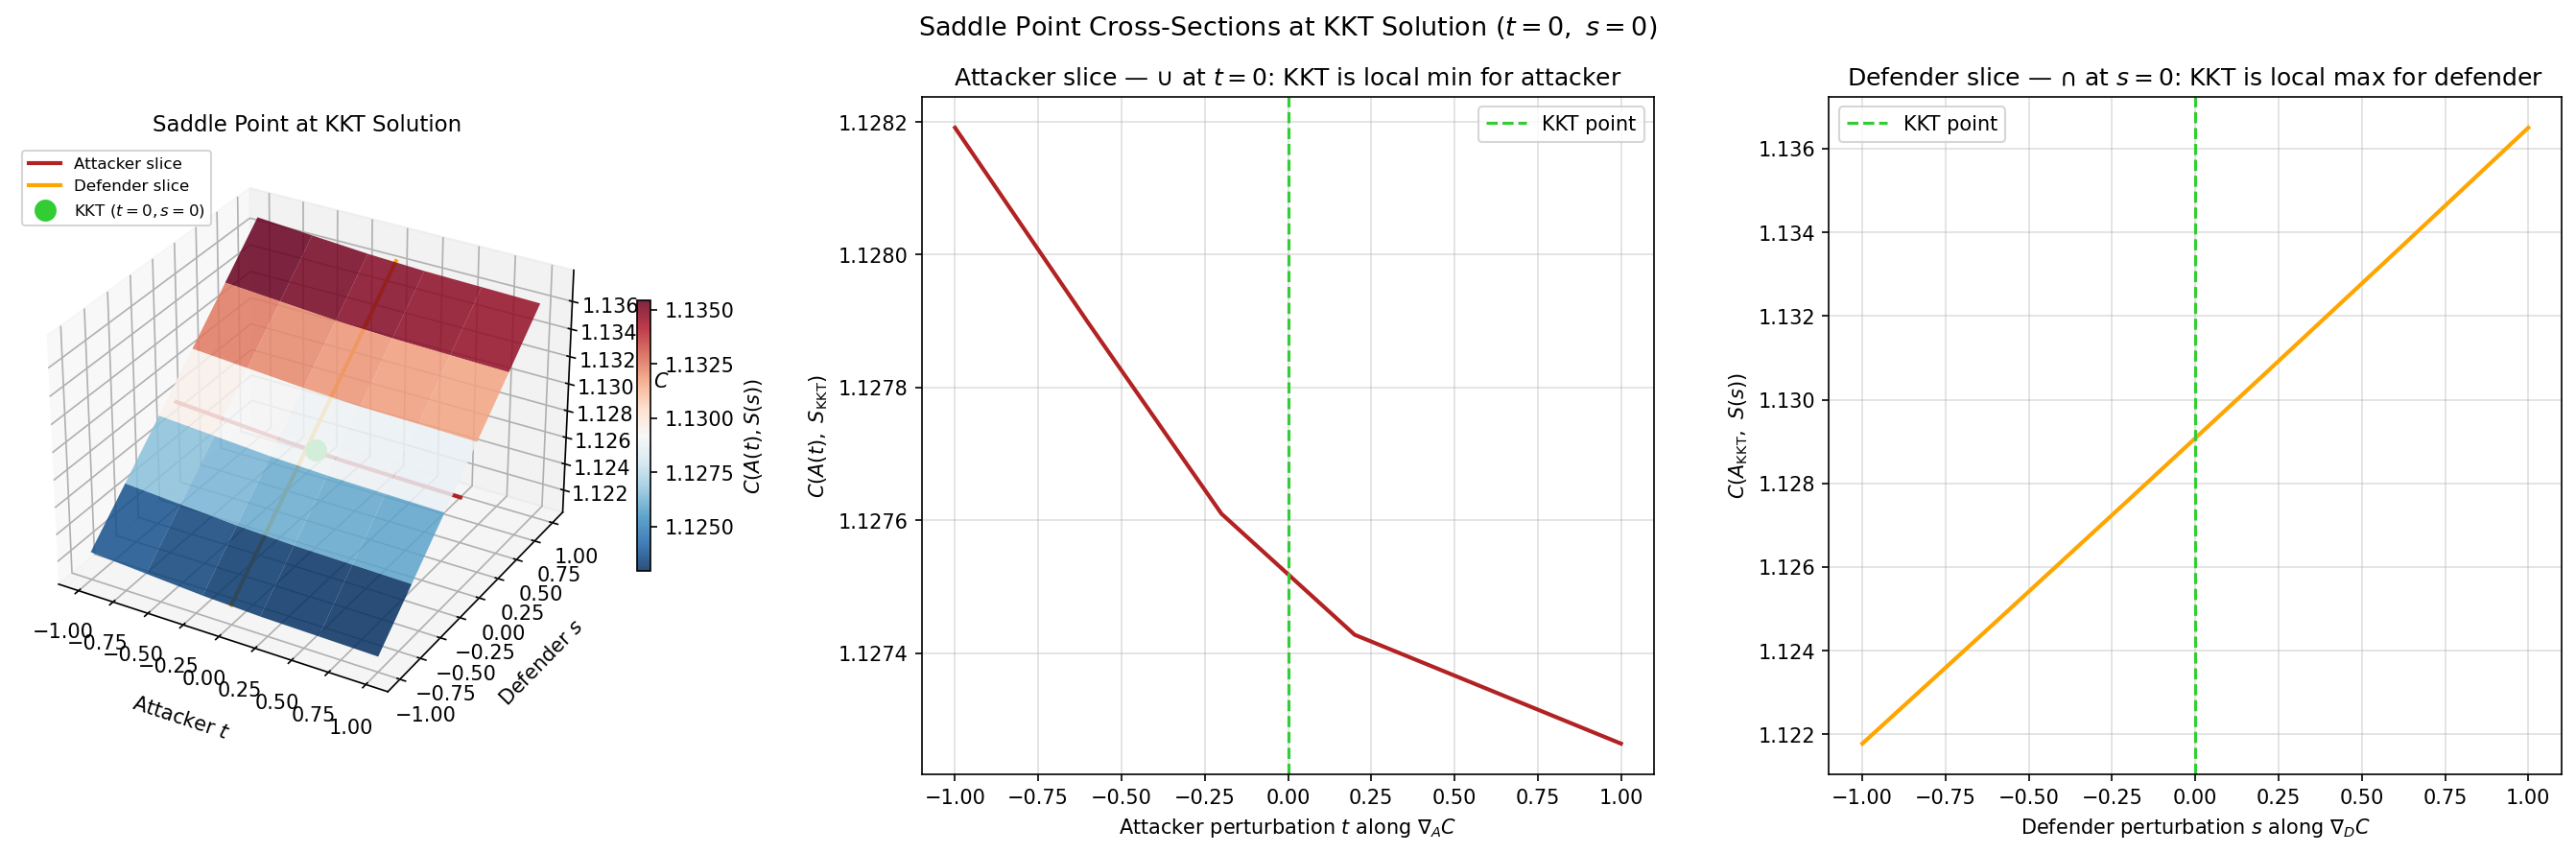


=== Saddle Point Check ===
  C at KKT (t=0, s=0):      1.127610
  Min along attacker slice:  1.127264  at t=1.000  (saddle: should be near 0)
  Max along defender slice:  1.136497  at s=1.000  (saddle: should be near 0)
  Attacker at local min: False
  Defender at local max: False
  KKT solution is NOT confirmed as local NE along these directions.
     Attacker min at t=1.000, not at t=0
     Defender max at s=1.000, not at s=0


In [20]:
##############################################################################
# --- Saddle Point Visualization (KKT Solution) ---
#
# Axes centered at KKT solution (A_kkt, S_kkt):
#   Attacker axis t: A(t) = A_kkt + t * scale_A * gA_unit
#     t=0: KKT point. At true NE: C minimized at t=0 (U-shape)
#   Defender axis s: S(s) = S_kkt + s * scale_D * gD_unit (2D Cartesian)
#     s=0: KKT point. At true NE: C maximized at s=0 (inverted U-shape)
# z-axis: C(A(t), S(s)) evaluated numerically
##############################################################################

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

T_kkt_val = float(A_kkt[2, -1] - A_kkt[2, 0])
Sx_kkt    = S_kkt[0, :].copy()
Sy_kkt    = S_kkt[1, :].copy()

# ------------------------------------------------------------------ #
#  Build gradient functions at KKT point
# ------------------------------------------------------------------ #
_x2  = ca.MX.sym('x2',  N_attk + 1)
_y2  = ca.MX.sym('y2',  N_attk + 1)
_T2  = ca.MX.sym('T2')
_Sx2 = ca.MX.sym('Sx2', cam_dict['n'])
_Sy2 = ca.MX.sym('Sy2', cam_dict['n'])
_dt2 = _T2 / N_attk

_S2 = ca.vertcat(
    ca.reshape(_Sx2, 1, cam_dict['n']),
    ca.reshape(_Sy2, 1, cam_dict['n'])
)

_cam2 = []
for i in range(cam_dict['n_direc']):
    _cam2.append(Camera(i, cam_dict,
                        float(cam_x_all[i]), float(cam_y_all[i])))

_t2  = [path[0][2] + i * _dt2 for i in range(N_attk + 1)]
_ls2 = 0
for i in range(N_attk + 1):
    xi = _x2[i]; yi = _y2[i]; ti = _t2[i]
    kp = 1.0
    for cam_i in range(cam_dict['n']):
        dxi = xi - _S2[0, cam_i]; dyi = yi - _S2[1, cam_i]
        dsq = dxi**2 + dyi**2
        dm  = ca.fmax(dsq, 1e-4); ds = ca.sqrt(dm)
        if cam_i < cam_dict['n_direc']:
            co  = _cam2[cam_i]
            phi = co.get_ctr_theta_t(ti); th = co.fov_ang
            ca_ = (dxi*ca.cos(phi) + dyi*ca.sin(phi)) / ds
            vis = 1 / (1 + ca.exp(-c_param*(ca_ - ca.cos(th/2))))
            obs = 1 / (1 + alpha_direc*dm)
        else:
            vis = 1.0; obs = 1 / (1 + alpha_omni*dm)
        kp *= (1 - vis*obs)
    _ls2 += -ca.log(1.0 - (1 - kp) + 1e-9)

_C2   = _ls2 - 0.02*_T2
_wA2  = ca.vertcat(_x2, _y2, _T2)
_wD2  = ca.vertcat(_Sx2, _Sy2)
_gA2  = ca.gradient(_C2, _wA2)
_gD2  = ca.gradient(_C2, _wD2)

inp2        = [_x2, _y2, _T2, _Sx2, _Sy2]
fn_gA_kkt   = ca.Function('gAk', inp2, [_gA2])
fn_gD_kkt   = ca.Function('gDk', inp2, [_gD2])
fn_C_kkt    = ca.Function('Ck',  inp2, [_C2])

# Evaluate gradients at KKT point
gA_vec = np.array(fn_gA_kkt(A_kkt[0,:], A_kkt[1,:], T_kkt_val,
                              Sx_kkt, Sy_kkt)).flatten()
gD_vec = np.array(fn_gD_kkt(A_kkt[0,:], A_kkt[1,:], T_kkt_val,
                              Sx_kkt, Sy_kkt)).flatten()

gA_norm = np.linalg.norm(gA_vec)
gD_norm = np.linalg.norm(gD_vec)
gA_unit = gA_vec / (gA_norm + 1e-9)
gD_unit = gD_vec / (gD_norm + 1e-9)

print(f'||grad_A|| at KKT = {gA_norm:.4e}')
print(f'||grad_D|| at KKT = {gD_norm:.4e}')
print(f'C at KKT:           {float(fn_C_kkt(A_kkt[0,:], A_kkt[1,:], T_kkt_val, Sx_kkt, Sy_kkt)):.6f}')

# ------------------------------------------------------------------ #
#  Grid setup
# ------------------------------------------------------------------ #
n_grid  = 6
scale_A = 0.5
scale_D = 0.5

t_range = np.linspace(-1.0, 1.0, n_grid)
s_range = np.linspace(-1.0, 1.0, n_grid)

print(f'Evaluating C on {n_grid}x{n_grid} grid...')
C_grid = np.zeros((n_grid, n_grid))

for i, t in enumerate(t_range):
    w_A_kkt = np.concatenate([A_kkt[0,:], A_kkt[1,:], [T_kkt_val]])
    w_A_t   = w_A_kkt - t * scale_A * gA_unit   # + along gradient

    x_t = w_A_t[:N_attk+1].copy()
    y_t = w_A_t[N_attk+1:2*(N_attk+1)].copy()
    T_t = float(np.clip(w_A_t[-1], 1e-3, float(path[-1][2])*1.5))
    x_t[0]  = x0[0];  y_t[0]  = x0[1]
    x_t[-1] = xf[0];  y_t[-1] = xf[1]

    for j_s, s in enumerate(s_range):
        Sx_s = Sx_kkt + s * scale_D * gD_unit[:cam_dict['n']]
        Sy_s = Sy_kkt + s * scale_D * gD_unit[cam_dict['n']:]
        S_s  = np.vstack([Sx_s, Sy_s])

        C_grid[i, j_s] = eval_C_numeric(
            np.vstack([x_t, y_t,
                       np.linspace(path[0][2], path[0][2]+T_t, N_attk+1)]),
            S_s
        )

    if (i + 1) % 5 == 0:
        print(f'  Row {i+1}/{n_grid} done')

print('Grid complete.')

# ------------------------------------------------------------------ #
#  Indices of center point (t=0, s=0)
# ------------------------------------------------------------------ #
t0 = np.argmin(np.abs(t_range))
s0 = np.argmin(np.abs(s_range))

T_mesh, S_mesh = np.meshgrid(t_range, s_range, indexing='ij')

# ------------------------------------------------------------------ #
#  Full figure: 3D surface + 2 cross-sections
# ------------------------------------------------------------------ #
fig = plt.figure(figsize=(18, 6), dpi=150)

ax3d = fig.add_subplot(131, projection='3d')
surf = ax3d.plot_surface(T_mesh, S_mesh, C_grid,
    cmap=cm.RdBu_r, alpha=0.85, linewidth=0, antialiased=True)
ax3d.plot(t_range, np.zeros(n_grid), C_grid[:, s0],
          '-', color='firebrick', lw=2.0, label=r'Attacker slice')
ax3d.plot(np.zeros(n_grid), s_range, C_grid[t0, :],
          '-', color='orange', lw=2.0, label=r'Defender slice')
ax3d.scatter([0], [0], [C_grid[t0, s0]],
             color='limegreen', s=100, zorder=10, label=r'KKT $(t=0,s=0)$')
fig.colorbar(surf, ax=ax3d, shrink=0.4, label=r'$C(A(t),S(s))$')
ax3d.set_xlabel(r'Attacker $t$', labelpad=8)
ax3d.set_ylabel(r'Defender $s$', labelpad=8)
ax3d.set_zlabel(r'$C$', labelpad=8)
ax3d.set_title(r'Saddle Point at KKT Solution', fontsize=11)
ax3d.legend(fontsize=8, loc='upper left')

ax_att = fig.add_subplot(132)
ax_att.plot(t_range, C_grid[:, s0], '-', color='firebrick', lw=2.0)
ax_att.axvline(x=0, color='limegreen', linestyle='--', lw=1.5, label='KKT point')
ax_att.set_xlabel(r'Attacker perturbation $t$ along $\nabla_A C$')
ax_att.set_ylabel(r'$C(A(t),\ S_{\rm KKT})$')
ax_att.set_title(r'Attacker slice — $\cup$ at $t=0$: KKT is local min for attacker')
ax_att.legend(); ax_att.grid(alpha=0.4)

ax_def = fig.add_subplot(133)
ax_def.plot(s_range, C_grid[t0, :], '-', color='orange', lw=2.0)
ax_def.axvline(x=0, color='limegreen', linestyle='--', lw=1.5, label='KKT point')
ax_def.set_xlabel(r'Defender perturbation $s$ along $\nabla_D C$')
ax_def.set_ylabel(r'$C(A_{\rm KKT},\ S(s))$')
ax_def.set_title(r'Defender slice — $\cap$ at $s=0$: KKT is local max for defender')
ax_def.legend(); ax_def.grid(alpha=0.4)

plt.suptitle(r'Saddle Point Cross-Sections at KKT Solution $(t=0,\ s=0)$',
             fontsize=13)
plt.tight_layout()
plt.savefig('image/AD_Game/' + timestamp + '_saddle_kkt.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------ #
#  Saddle check
# ------------------------------------------------------------------ #
print()
print('=== Saddle Point Check ===')
C_center  = C_grid[t0, s0]
t_min_idx = np.argmin(C_grid[:, s0])
s_max_idx = np.argmax(C_grid[t0, :])
print(f'  C at KKT (t=0, s=0):      {C_center:.6f}')
print(f'  Min along attacker slice:  {np.min(C_grid[:,s0]):.6f}'
      f'  at t={t_range[t_min_idx]:.3f}  (saddle: should be near 0)')
print(f'  Max along defender slice:  {np.max(C_grid[t0,:]):.6f}'
      f'  at s={s_range[s_max_idx]:.3f}  (saddle: should be near 0)')
att_is_min = abs(t_range[t_min_idx]) < 0.15
def_is_max = abs(s_range[s_max_idx]) < 0.15
print(f'  Attacker at local min: {att_is_min}')
print(f'  Defender at local max: {def_is_max}')
if att_is_min and def_is_max:
    print('  KKT solution is a local Nash Equilibrium!')
else:
    print('  KKT solution is NOT confirmed as local NE along these directions.')
    if not att_is_min:
        print(f'     Attacker min at t={t_range[t_min_idx]:.3f}, not at t=0')
    if not def_is_max:
        print(f'     Defender max at s={s_range[s_max_idx]:.3f}, not at s=0')

In [ ]:
# Rebuild gradient function using S_star positions for camera headings
_x3  = ca.MX.sym('x3',  N_attk + 1)
_y3  = ca.MX.sym('y3',  N_attk + 1)
_T3  = ca.MX.sym('T3')
_Sx3 = ca.MX.sym('Sx3', cam_dict['n'])
_Sy3 = ca.MX.sym('Sy3', cam_dict['n'])
_dt3 = _T3 / N_attk
_S3  = ca.vertcat(
    ca.reshape(_Sx3, 1, cam_dict['n']),
    ca.reshape(_Sy3, 1, cam_dict['n'])
)

# Use S_star positions for directional sensor heading model
_cams3 = []
for i in range(cam_dict['n_direc']):
    _cams3.append(Camera(i, cam_dict,
                         float(S_star[0, i]),   # <- S_star, not cam_x_all
                         float(S_star[1, i])))  # <- S_star, not cam_y_all

_t3  = [path[0][2] + i * _dt3 for i in range(N_attk + 1)]
_ls3 = 0
for i in range(N_attk + 1):
    xi = _x3[i]; yi = _y3[i]; ti = _t3[i]
    kp = 1.0
    for cam_i in range(cam_dict['n']):
        dxi = xi - _S3[0, cam_i]; dyi = yi - _S3[1, cam_i]
        dsq = dxi**2 + dyi**2
        dm  = ca.fmax(dsq, 1e-4); ds = ca.sqrt(dm)
        if cam_i < cam_dict['n_direc']:
            co  = _cams3[cam_i]
            phi = co.get_ctr_theta_t(ti); th = co.fov_ang
            ca_ = (dxi*ca.cos(phi) + dyi*ca.sin(phi)) / ds
            vis = 1 / (1 + ca.exp(-c_param*(ca_ - ca.cos(th/2))))
            obs = 1 / (1 + alpha_direc*dm)
        else:
            vis = 1.0; obs = 1 / (1 + alpha_omni*dm)
        kp *= (1 - vis*obs)
    _ls3 += -ca.log(1.0 - (1 - kp) + 1e-9)

_C3  = _ls3 - 0.02*_T3
_wD3 = ca.vertcat(_Sx3, _Sy3)
_gD3 = ca.gradient(_C3, _wD3)

inp3     = [_x3, _y3, _T3, _Sx3, _Sy3]
fn_gD_abr = ca.Function('gD_abr', inp3, [_gD3])

# Now recheck tangential gradients
T_abr_val = float(A_star[2,-1] - A_star[2,0])
gD_abr = np.array(fn_gD_abr(A_star[0,:], A_star[1,:], T_abr_val,
                              S_star[0,:], S_star[1,:])).flatten()

def get_sensor_tangent(j, S, A_ref, defender_boundary,
                        sensor_building_idx, eps=0.05, eps_test=0.1):
    """
    For sensor j, compute the unit tangent vector along the building edge
    oriented in the direction that INCREASES C (ascent direction).
    """
    b_idx = sensor_building_idx[j]
    A_obs = defender_boundary[b_idx]['A']
    b_obs = defender_boundary[b_idx]['b']
    xy    = S[:, j]

    # Outward normal via log-sum-exp gradient (Eq. 27 from paper)
    logits = (A_obs @ xy - b_obs) / eps
    m      = logits.max()
    w      = np.exp(logits - m); w /= w.sum()
    n      = -(A_obs.T @ w)
    n      = n / (np.linalg.norm(n) + 1e-12)

    # Tangent = 90 degree rotation of normal
    t_raw = np.array([-n[1], n[0]])

    # Test which direction increases C — pick ascent direction
    S_plus       = S.copy()
    S_plus[0, j] += eps_test * t_raw[0]
    S_plus[1, j] += eps_test * t_raw[1]
    S_minus       = S.copy()
    S_minus[0, j] -= eps_test * t_raw[0]
    S_minus[1, j] -= eps_test * t_raw[1]

    C_plus  = eval_C_numeric(A_ref, S_plus)
    C_minus = eval_C_numeric(A_ref, S_minus)

    return t_raw if C_plus >= C_minus else -t_raw


print("Defender tangential gradient at ABR solution (corrected):")
for j in range(cam_dict['n']):
    tan_j    = get_sensor_tangent(j, S_star, A_star,
                                   defender_boundary, sensor_building_idx)
    gD_j     = np.array([gD_abr[j], gD_abr[cam_dict['n']+j]])
    gD_tan_j = np.dot(gD_j, tan_j)
    print(f"  Sensor {j}: tangential grad = {gD_tan_j:.6e}  "
          f"(~0 means at constrained max)")

Defender tangential gradient at ABR solution (corrected):
  Sensor 0: tangential grad = 2.674432e-04  (~0 means at constrained max)
  Sensor 1: tangential grad = 4.975370e-04  (~0 means at constrained max)
  Sensor 2: tangential grad = 6.241792e-03  (~0 means at constrained max)
  Sensor 3: tangential grad = 4.055685e-03  (~0 means at constrained max)
  Sensor 4: tangential grad = 5.766460e-04  (~0 means at constrained max)
  Sensor 5: tangential grad = 2.286609e-05  (~0 means at constrained max)
  Sensor 6: tangential grad = 1.649217e-03  (~0 means at constrained max)
  Sensor 7: tangential grad = 6.867421e-03  (~0 means at constrained max)
  Sensor 8: tangential grad = 4.255051e-03  (~0 means at constrained max)
  Sensor 9: tangential grad = 5.936132e-04  (~0 means at constrained max)



Computing feasible saddle grid for KKT...
  Row 5/5 done

Computing feasible saddle grid for ABR...
  Row 5/5 done

=== Saddle Check: KKT (Simultaneous) ===
  C at center:              1.128937
  Attacker min at t=0.500  (want ~0): False
  Defender max at s=1.000  (want ~0): False
  ❌ KKT (Simultaneous) not confirmed as local NE.

=== Saddle Check: ABR (Bilevel) ===
  C at center:              1.637592
  Attacker min at t=0.500  (want ~0): False
  Defender max at s=1.000  (want ~0): False
  ❌ ABR (Bilevel) not confirmed as local NE.


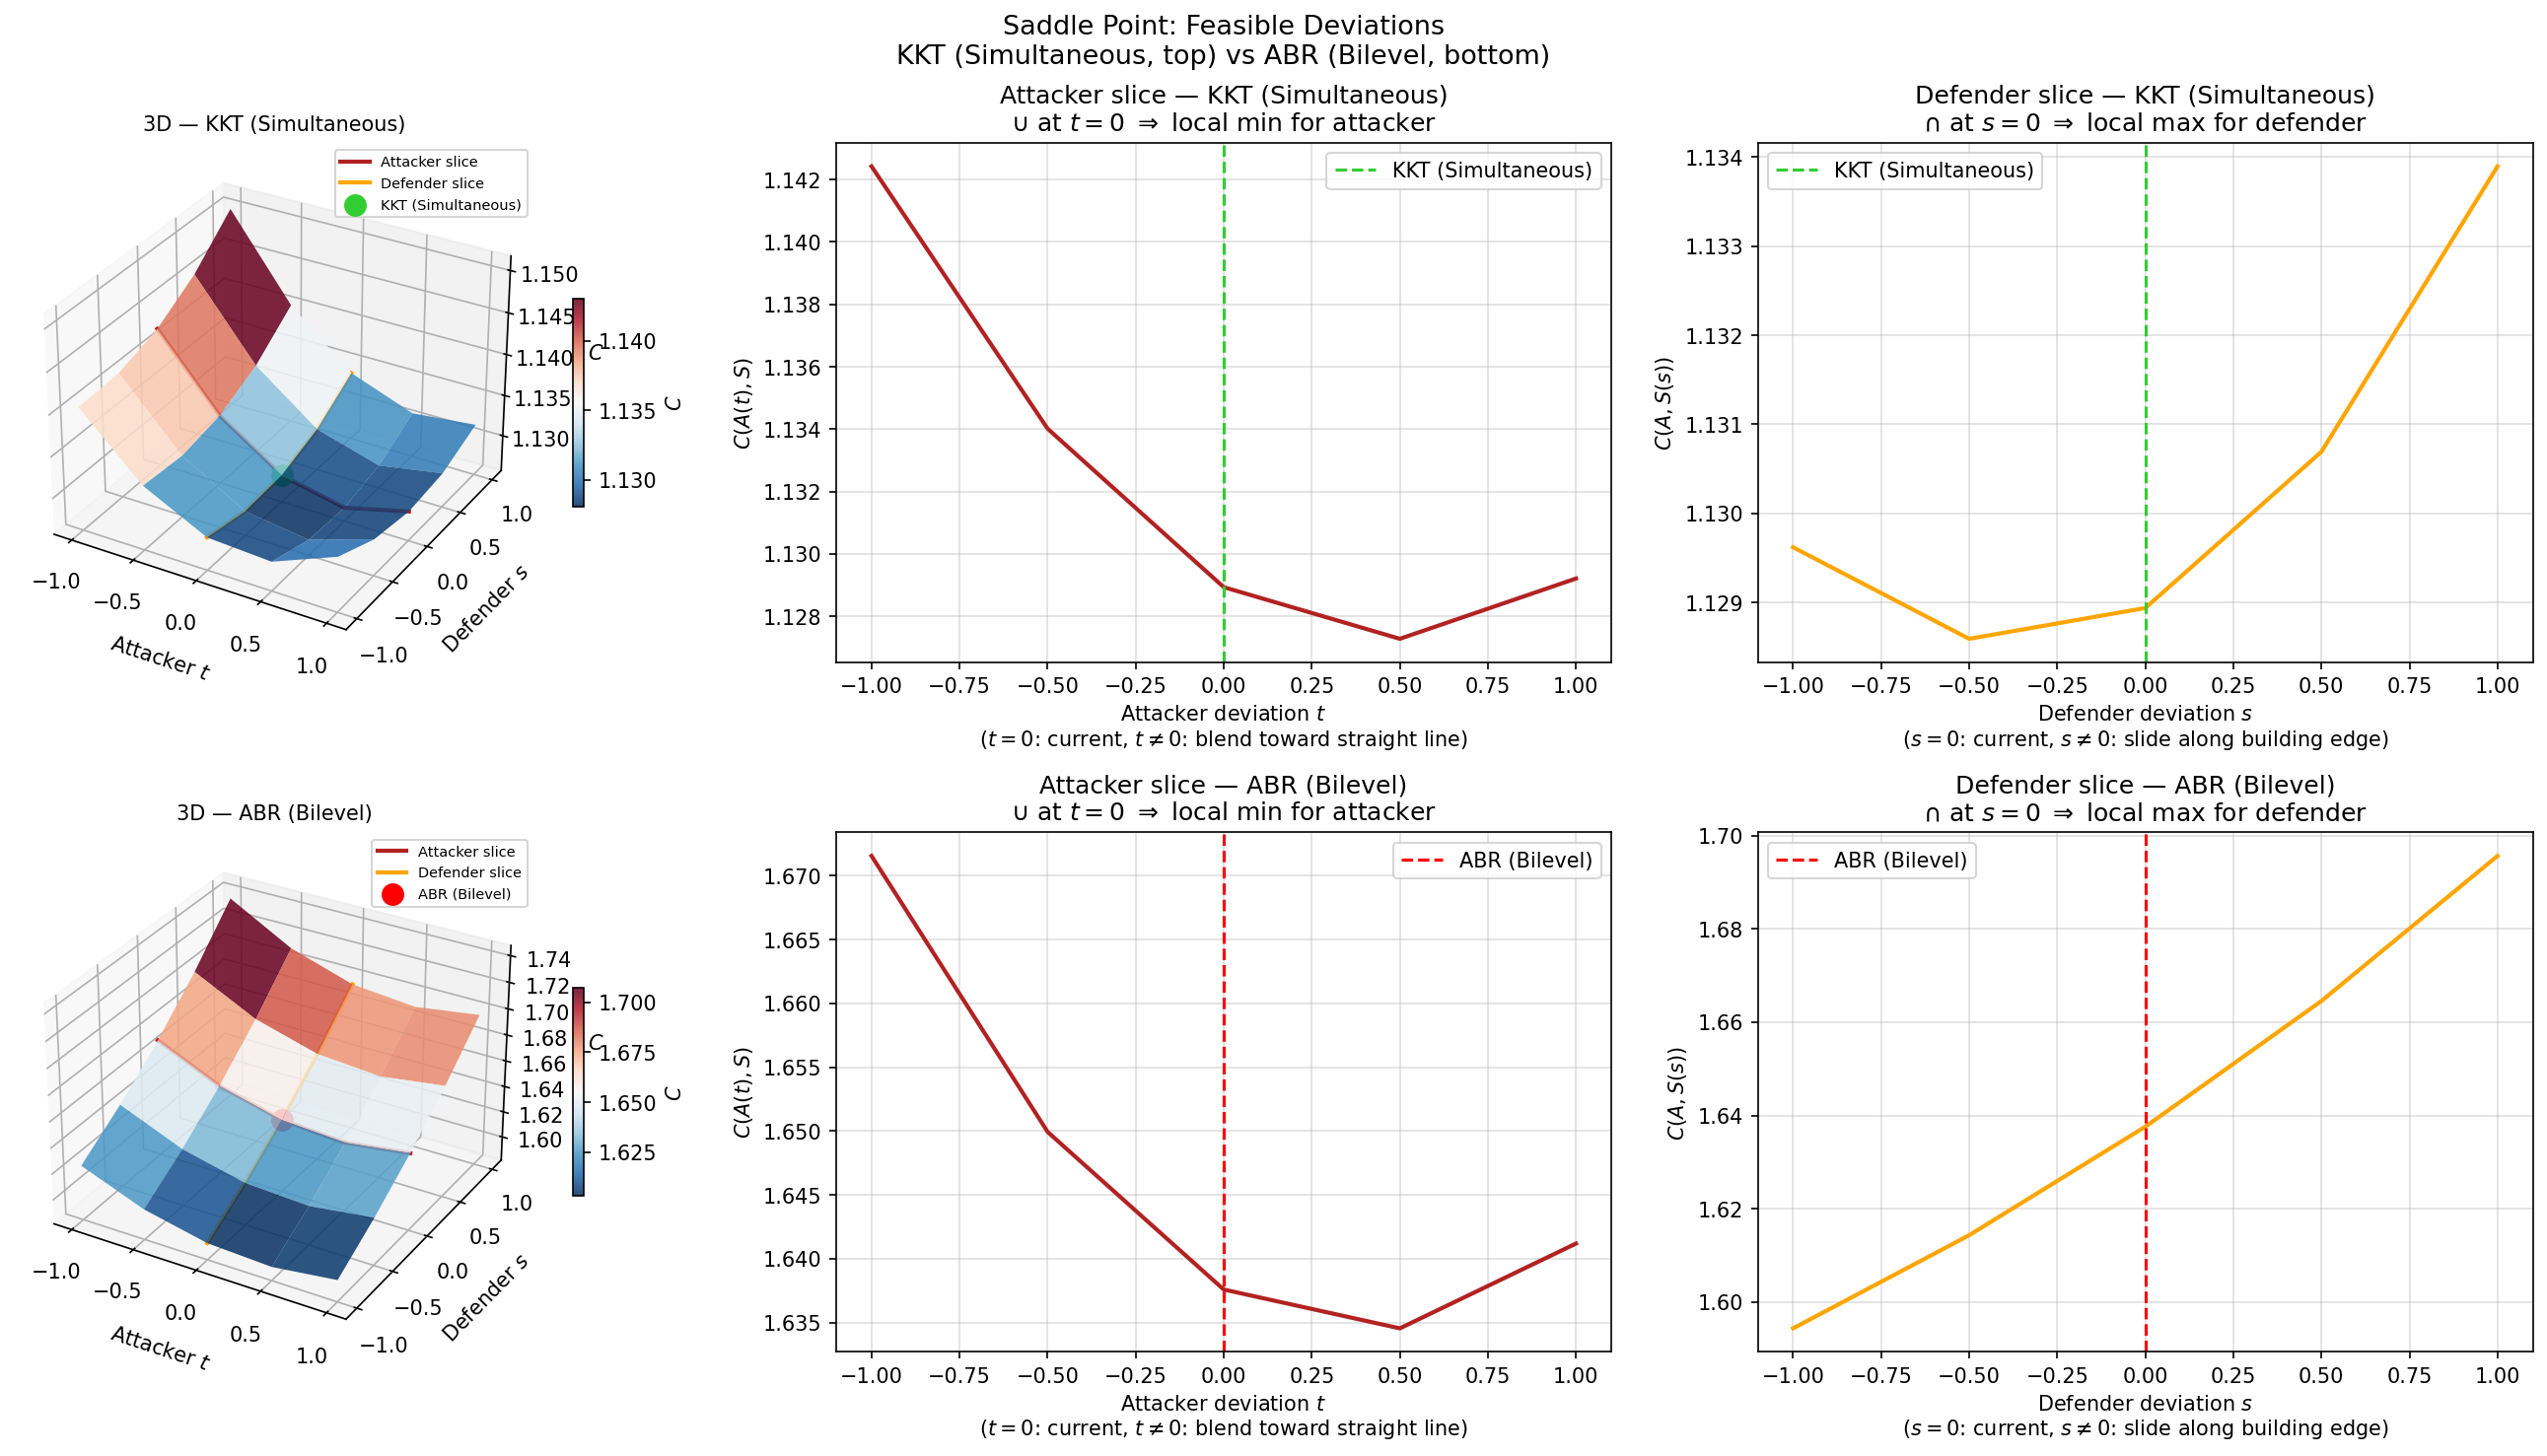

In [30]:
##############################################################################
# --- Saddle Point Visualization: Feasible Perturbations ---
#
# Correct approach for constrained LNE verification:
#
# Attacker axis: perturb A_star along a feasible trajectory deviation
#   — scale the trajectory waypoints toward/away from a straight line
#   — feasible: stays collision-free and respects speed limits approximately
#
# Defender axis: perturb S_star along the TANGENTIAL direction of the
#   building edge for each sensor — the only direction the defender can
#   actually move while staying on the boundary
#
# At a true LNE:
#   - Attacker slice: C increases as attacker deviates (U-shape)
#   - Defender slice: C decreases as defender deviates (inverted U-shape)
##############################################################################

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# ------------------------------------------------------------------ #
#  Helper: get tangential direction for each sensor on its building edge
# ------------------------------------------------------------------ #
def get_tangent_directions(S, sensor_building_idx, defender_boundary, eps=0.05):
    """
    For each sensor, compute the unit tangent vector along the building edge.
    Uses grad_R to get the outward normal, then rotates 90 degrees.
    """
    tangents = np.zeros((2, len(sensor_building_idx)))
    for j in range(len(sensor_building_idx)):
        b_idx = sensor_building_idx[j]
        A_obs = defender_boundary[b_idx]['A']
        b_obs = defender_boundary[b_idx]['b']
        xy    = S[:, j]
        # Outward normal via log-sum-exp gradient
        logits = (A_obs @ xy - b_obs) / eps
        m = logits.max()
        w = np.exp(logits - m); w /= w.sum()
        n = -(A_obs.T @ w)           # outward normal (2,)
        n = n / (np.linalg.norm(n) + 1e-12)
        # Tangent = 90 degree rotation of normal
        t = np.array([-n[1], n[0]])  # (2,)
        tangents[:, j] = t
    return tangents

# ------------------------------------------------------------------ #
#  Helper: feasible attacker perturbation
#   Interpolates between current trajectory and a straight line path
#   t=0: current trajectory
#   t>0: moves toward straight line (less optimal evasion)
#   t<0: moves away from straight line (more curved)
# ------------------------------------------------------------------ #
# def perturb_attacker(A_ctr, t, scale=1.0):
#     """Perturb attacker by blending with straight-line trajectory."""
#     x_c = A_ctr[0,:].copy()
#     y_c = A_ctr[1,:].copy()
#     T_c = float(A_ctr[2,-1] - A_ctr[2,0])
#     N   = len(x_c) - 1

#     # Straight line from start to goal
#     x_line = np.linspace(x0[0], xf[0], N+1)
#     y_line = np.linspace(x0[1], xf[1], N+1)

#     # Blend: x(t) = x_c + t*scale*(x_line - x_c)
#     alpha = t * scale
#     x_new = x_c + alpha * (x_line - x_c)
#     y_new = y_c + alpha * (y_line - y_c)

#     # Enforce boundary conditions
#     x_new[0]  = x0[0]; y_new[0]  = x0[1]
#     x_new[-1] = xf[0]; y_new[-1] = xf[1]

#     t_new = np.linspace(A_ctr[2,0], A_ctr[2,-1], N+1)
#     return np.vstack([x_new, y_new, t_new])
def perturb_attacker(A_ctr, t, scale=0.5):
    x_c = A_ctr[0,:].copy()
    y_c = A_ctr[1,:].copy()
    N   = len(x_c) - 1
    
    # Perpendicular sinusoidal bump — zero at endpoints
    s_param = np.linspace(0, np.pi, N+1)
    bump    = np.sin(s_param)  # zero at endpoints, peak in middle
    
    # Trajectory tangent direction at each point
    dx = np.gradient(x_c); dy = np.gradient(y_c)
    norms = np.sqrt(dx**2 + dy**2) + 1e-9
    # Perpendicular to tangent
    perp_x = -dy / norms
    perp_y =  dx / norms
    
    x_new = x_c + t * scale * bump * perp_x
    y_new = y_c + t * scale * bump * perp_y
    
    # Enforce boundary conditions
    x_new[0]  = x0[0]; y_new[0]  = x0[1]
    x_new[-1] = xf[0]; y_new[-1] = xf[1]
    
    t_new = np.linspace(A_ctr[2,0], A_ctr[2,-1], N+1)
    return np.vstack([x_new, y_new, t_new])

# ------------------------------------------------------------------ #
#  Helper: feasible defender perturbation along building edge tangent
# ------------------------------------------------------------------ #
def perturb_defender(S_ctr, s, tangents, scale=2.0):
    """
    Perturb each sensor along its building edge tangent direction.
    s=0: current position
    s>0: all sensors move in +tangent direction
    s<0: all sensors move in -tangent direction
    """
    Sx_new = S_ctr[0,:] + s * scale * tangents[0,:]
    Sy_new = S_ctr[1,:] + s * scale * tangents[1,:]
    return np.vstack([Sx_new, Sy_new])

# ------------------------------------------------------------------ #
#  Compute saddle grid using feasible perturbations
# ------------------------------------------------------------------ #
# def compute_feasible_saddle_grid(A_ctr, S_ctr, label, n_grid=25,
#                                   scale_A=1.0, scale_D=2.0):
#     print(f'\nComputing feasible saddle grid for {label}...')
#     tangents = get_tangent_directions(S_ctr, sensor_building_idx,
#                                        defender_boundary)

#     t_range = np.linspace(-1.0, 1.0, n_grid)
#     s_range = np.linspace(-1.0, 1.0, n_grid)
#     C_grid  = np.zeros((n_grid, n_grid))

#     for i, t in enumerate(t_range):
#         A_t = perturb_attacker(A_ctr, t, scale=scale_A)
#         for j, s in enumerate(s_range):
#             S_s = perturb_defender(S_ctr, s, tangents, scale=scale_D)
#             C_grid[i,j] = eval_C_numeric(A_t, S_s)

#         if (i+1) % 5 == 0:
#             print(f'  Row {i+1}/{n_grid} done')

#     return t_range, s_range, C_grid

def compute_feasible_saddle_grid(A_ctr, S_ctr, label, n_grid=25,
                                  scale_A=2.0, scale_D=0.5):
    print(f'\nComputing feasible saddle grid for {label}...')

    # Get per-sensor ascent-oriented tangents
    tangents = np.zeros((2, cam_dict['n']))
    for j in range(cam_dict['n']):
        tangents[:, j] = get_sensor_tangent(
            j, S_ctr, A_ctr, defender_boundary, sensor_building_idx)

    t_range = np.linspace(-1.0, 1.0, n_grid)
    s_range = np.linspace(-1.0, 1.0, n_grid)
    C_grid  = np.zeros((n_grid, n_grid))

    for i, t in enumerate(t_range):
        A_t = perturb_attacker(A_ctr, t, scale_A)
        for j_s, s in enumerate(s_range):
            # Move ALL sensors simultaneously along their ascent tangents
            S_s = S_ctr.copy()
            for j in range(cam_dict['n']):
                S_s[0, j] += s * scale_D * tangents[0, j]
                S_s[1, j] += s * scale_D * tangents[1, j]
            C_grid[i, j_s] = eval_C_numeric(A_t, S_s)

        if (i+1) % 5 == 0:
            print(f'  Row {i+1}/{n_grid} done')

    return t_range, s_range, C_grid

# ------------------------------------------------------------------ #
#  Compute grids
# ------------------------------------------------------------------ #
n_grid = 5

t_kkt, s_kkt, Cg_kkt = compute_feasible_saddle_grid(
    A_kkt, S_kkt, 'KKT', n_grid, scale_A=2, scale_D=2)

t_abr, s_abr, Cg_abr = compute_feasible_saddle_grid(
    A_star, S_star, 'ABR', n_grid, scale_A=2, scale_D=2)

# ------------------------------------------------------------------ #
#  Plot: 2 rows x 3 cols
# ------------------------------------------------------------------ #
fig = plt.figure(figsize=(18, 10), dpi=150)

for row, (t_r, s_r, C_g, label, color_pt) in enumerate([
    (t_kkt, s_kkt, Cg_kkt, 'KKT (Simultaneous)', 'limegreen'),
    (t_abr, s_abr, Cg_abr, 'ABR (Bilevel)',       'red'),
]):
    t0 = np.argmin(np.abs(t_r))
    s0 = np.argmin(np.abs(s_r))
    T_mesh, S_mesh = np.meshgrid(t_r, s_r, indexing='ij')

    # 3D surface
    ax3d = fig.add_subplot(2, 3, row*3+1, projection='3d')
    surf = ax3d.plot_surface(T_mesh, S_mesh, C_g,
        cmap=cm.RdBu_r, alpha=0.85, linewidth=0, antialiased=True)
    ax3d.plot(t_r, np.zeros(len(t_r)), C_g[:,s0],
              '-', color='firebrick', lw=2.0, label='Attacker slice')
    ax3d.plot(np.zeros(len(s_r)), s_r, C_g[t0,:],
              '-', color='orange',   lw=2.0, label='Defender slice')
    ax3d.scatter([0],[0],[C_g[t0,s0]], color=color_pt, s=100,
                 zorder=10, label=label)
    fig.colorbar(surf, ax=ax3d, shrink=0.4, label=r'$C$')
    ax3d.set_xlabel(r'Attacker $t$', labelpad=6)
    ax3d.set_ylabel(r'Defender $s$', labelpad=6)
    ax3d.set_zlabel(r'$C$', labelpad=6)
    ax3d.set_title(f'3D — {label}', fontsize=10)
    ax3d.legend(fontsize=7)

    # Attacker slice
    ax_att = fig.add_subplot(2, 3, row*3+2)
    ax_att.plot(t_r, C_g[:,s0], '-', color='firebrick', lw=2.0)
    ax_att.axvline(x=0, color=color_pt, linestyle='--', lw=1.5,
                   label=f'{label}')
    ax_att.set_xlabel(r'Attacker deviation $t$' + '\n' +
                      r'($t=0$: current, $t\neq0$: blend toward straight line)')
    ax_att.set_ylabel(r'$C(A(t), S)$')
    ax_att.set_title(f'Attacker slice — {label}\n'
                     r'$\cup$ at $t=0$ $\Rightarrow$ local min for attacker')
    ax_att.legend(); ax_att.grid(alpha=0.4)

    # Defender slice
    ax_def = fig.add_subplot(2, 3, row*3+3)
    ax_def.plot(s_r, C_g[t0,:], '-', color='orange', lw=2.0)
    ax_def.axvline(x=0, color=color_pt, linestyle='--', lw=1.5,
                   label=f'{label}')
    ax_def.set_xlabel(r'Defender deviation $s$' + '\n' +
                      r'($s=0$: current, $s\neq0$: slide along building edge)')
    ax_def.set_ylabel(r'$C(A, S(s))$')
    ax_def.set_title(f'Defender slice — {label}\n'
                     r'$\cap$ at $s=0$ $\Rightarrow$ local max for defender')
    ax_def.legend(); ax_def.grid(alpha=0.4)

    # Saddle check
    t_min_idx = np.argmin(C_g[:,s0])
    s_max_idx = np.argmax(C_g[t0,:])
    att_ok = abs(t_r[t_min_idx]) < 0.15
    def_ok = abs(s_r[s_max_idx]) < 0.15
    print(f'\n=== Saddle Check: {label} ===')
    print(f'  C at center:              {C_g[t0,s0]:.6f}')
    print(f'  Attacker min at t={t_r[t_min_idx]:.3f}  (want ~0): {att_ok}')
    print(f'  Defender max at s={s_r[s_max_idx]:.3f}  (want ~0): {def_ok}')
    if att_ok and def_ok:
        print(f'  ✅ {label} is a local Nash Equilibrium!')
    else:
        print(f'  ❌ {label} not confirmed as local NE.')

plt.suptitle('Saddle Point: Feasible Deviations\n'
             'KKT (Simultaneous, top) vs ABR (Bilevel, bottom)',
             fontsize=13)
plt.tight_layout()
plt.savefig('image/AD_Game/' + timestamp + '_saddle_feasible.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [31]:
T_abr_val = float(A_star[2,-1] - A_star[2,0])
gD_abr_corrected = np.array(fn_gD_abr(
    A_star[0,:], A_star[1,:], T_abr_val,
    S_star[0,:], S_star[1,:])).flatten()

print("Corrected tangential gradients at ABR:")
total_tan = 0
for j in range(cam_dict['n']):
    tan_j    = get_sensor_tangent(j, S_star, A_star,
                                   defender_boundary, sensor_building_idx)
    gD_j     = np.array([gD_abr_corrected[j],
                          gD_abr_corrected[cam_dict['n']+j]])
    gD_tan_j = np.dot(gD_j, tan_j)
    total_tan += abs(gD_tan_j)
    print(f"  Sensor {j}: tangential grad = {gD_tan_j:.6e}")
print(f"  Sum |tangential grads| = {total_tan:.6e}")

Corrected tangential gradients at ABR:
  Sensor 0: tangential grad = 2.674432e-04
  Sensor 1: tangential grad = 4.975370e-04
  Sensor 2: tangential grad = 6.241792e-03
  Sensor 3: tangential grad = 4.055685e-03
  Sensor 4: tangential grad = 5.766460e-04
  Sensor 5: tangential grad = 2.286609e-05
  Sensor 6: tangential grad = 1.649217e-03
  Sensor 7: tangential grad = 6.867421e-03
  Sensor 8: tangential grad = 4.255051e-03
  Sensor 9: tangential grad = 5.936132e-04
  Sum |tangential grads| = 2.502727e-02


In [27]:
# Check if S_star matches the camera positions used in fn_gD_kkt
print("S_star sensor positions:")
for j in range(cam_dict['n']):
    print(f"  Sensor {j}: S_star=({S_star[0,j]:.3f},{S_star[1,j]:.3f})  "
          f"cam_dict=({cam_x_all[j]:.3f},{cam_y_all[j]:.3f})")

S_star sensor positions:
  Sensor 0: S_star=(38.570,78.548)  cam_dict=(46.486,71.926)
  Sensor 1: S_star=(20.888,83.063)  cam_dict=(33.641,16.157)
  Sensor 2: S_star=(47.535,70.571)  cam_dict=(28.973,74.135)
  Sensor 3: S_star=(28.418,16.740)  cam_dict=(21.611,85.972)
  Sensor 4: S_star=(90.042,66.731)  cam_dict=(96.385,67.844)
  Sensor 5: S_star=(10.522,45.510)  cam_dict=(95.040,38.124)
  Sensor 6: S_star=(38.570,78.548)  cam_dict=(27.859,17.586)
  Sensor 7: S_star=(27.147,18.668)  cam_dict=(12.045,46.289)
  Sensor 8: S_star=(89.659,40.210)  cam_dict=(91.220,60.464)
  Sensor 9: S_star=(90.042,66.731)  cam_dict=(30.363,74.774)


In [33]:
# Check what optimize_defender returns
result = optimize_defender(A_star)
print(type(result))
print(result if not hasattr(result, '__len__') else result[0] if isinstance(result, tuple) else result)

<class 'tuple'>
[9.99929408e-01 9.99953017e-01 9.99994587e-01 2.64867557e-06
 9.99994198e-01 2.54547975e-01 9.99998329e-01 2.39259706e-06
 9.99997289e-01 1.63759027e-06]


In [32]:
# Run one more defender optimization from S_star given A_star
S_improved = optimize_defender(A_star)
C_improved  = eval_C_numeric(A_star, S_improved)
C_current   = eval_C_numeric(A_star, S_star)
print(f"C with S_star:    {C_current:.6f}")
print(f"C with S_improved: {C_improved:.6f}")
print(f"Improvement:       {C_improved - C_current:.6e}")

AttributeError: 'tuple' object has no attribute 'shape'

In [23]:
# -------------------------------------------------------
# Attacker best-response (ABR):
#   A_star   = attacker's best response (from last optimize_attacker call)
#   S_init   = INITIAL defender placement (the baseline)
# -------------------------------------------------------
# J_A: what the attacker achieves against the initial defender
log_sum_abr_A = eval_C_numeric(A_star, S_init)
J_A_abr = 1.0 - np.exp(-log_sum_abr_A)
print(f"J_A (Attacker BR vs S_init): {J_A_abr:.6f}")

# J_D: what the defender suffers when attacker plays BR against initial S
log_sum_abr_D = eval_C_numeric(A_star, S_init)  # same game value (zero-sum)
J_D_abr = 1.0 - np.exp(-log_sum_abr_D)
print(f"J_D (Attacker BR vs S_init): {J_D_abr:.6f}")

# Save sol_a for attacker BR
sol_a_abr = sol_a   # the CasADi solution object from optimize_attacker
A_star_abr = A_star.copy()  # (3, N_attk+1) numpy array

# -------------------------------------------------------
# Defender best-response (DBR):
#   S_star   = defender's best response (from last optimize_defender call)
#   A_initial = INITIAL attacker path (from STP-RRT*)
# -------------------------------------------------------
# J_D: what the defender achieves against the initial attacker
log_sum_dbr_D = eval_C_numeric(A_initial, S_star)
J_D_dbr = 1.0 - np.exp(-log_sum_dbr_D)
print(f"J_D (Defender BR vs A_init): {J_D_dbr:.6f}")

# J_A: what the attacker suffers when defender plays BR against initial A
log_sum_dbr_A = eval_C_numeric(A_initial, S_star)  # same game value
J_A_dbr = 1.0 - np.exp(-log_sum_dbr_A)
print(f"J_A (Defender BR vs A_init): {J_A_dbr:.6f}")

# Save sol_d for defender BR
sol_d_abr = sol_d   # the CasADi solution object from optimize_defender
S_star_dbr = S_star.copy()  # (2, M) numpy array
alpha_star_dbr = alpha_star.copy()  # (M,) numpy array

# J_A: what attacker gets at (A_star, S_star) — the paired strategies
log_A = eval_C_numeric(A_star, S_star)
J_A   = 1.0 - np.exp(-log_A)   # attacker wants this HIGH

# J_D: what defender gets at (A_star, S_star) — same pair, same value
# (zero-sum: J_D = J_A by definition in this game)
J_D   = J_A
print(f"Payoff at current strategies: J = {J_A:.6f}")

J_A (Attacker BR vs S_init): 0.783087
J_D (Attacker BR vs S_init): 0.783087
J_D (Defender BR vs A_init): 0.180524
J_A (Defender BR vs A_init): 0.180524
Payoff at current strategies: J = 0.805552
